In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
# Load data
data_dir = Path('/home/niclasflehmig/VisualCodeProjects/H2-dispersion-model/data')
df = pd.read_csv(data_dir / 'unified_raw_two_modes.csv')
df_uncut = pd.read_csv(data_dir /'unified_raw.csv')

In [3]:
SENSOR_POSITIONS = {
        1: (0.77, 0.24, 0.8), 2: (0.46, 0.0, 0.8), 3: (0.48, 0.25, 0.52),
        4: (0.13, 0.26, 0.8), 5: (0.48, 1.33, 0.52), 6: (0.46, 1.11, 0.8),
        7: (0.9, 2.22, 0.8), 8: (0.47, 2.46, 0.52), 9: (0.46, 2.22, 0.8),
        10: (0.74, 2.45, 0.8), 11: (0.15, 2.44, 0.8), 12: (0.00, 2.22, 0.8),
        13: (0.47, 3.54, 0.52), 14: (0.46, 3.31, 0.8), 15: (0.78, 4.65, 0.8),
        17: (0.46, 4.39, 0.8), 18: (0.47, 4.63, 0.52), 19: (0.14, 4.68, 0.52),
        20: (0.75, 0.24, 0.0), 21: (0.45, 0.0, 0.0), 22: (0.16, 0.24, 0.0),
        23: (0.47, 0.24, 0.28), 24: (0.46, 1.33, 0.27), 25: (0.47, 1.1, 0.0),
        26: (0.46, 2.46, 0.27), 27: (0.47, 2.23, 0.0), 28: (0.47, 3.56, 0.27),
        29: (0.47, 4.63, 0.27), 30: (0.46, 4.44, 0.0),
    }

In [3]:
df.head()

,time,mass_flow,sensor_id,x,y,z,h2_volume_fraction,source,scenario,experiment_id,split
0,0.000000,0.086,1,0.45,0.24,0.8,1.000000e-08,cfd,A,CFD_A,train
1,0.631053,0.086,1,0.45,0.24,0.8,1.000000e-08,cfd,A,CFD_A,train
2,1.262105,0.086,1,0.45,0.24,0.8,9.952579e-04,cfd,A,CFD_A,train
3,1.893158,0.086,1,0.45,0.24,0.8,6.282511e-03,cfd,A,CFD_A,train
4,2.524211,0.086,1,0.45,0.24,0.8,1.797501e-02,cfd,A,CFD_A,train


In [11]:
df_uncut.describe()

,time,mass_flow,sensor_id,x,y,z,h2_volume_fraction
count,296665.000000,296665.000000,296665.000000,296665.000000,296665.000000,296665.000000,2.966650e+05
mean,108.789936,0.384129,15.496257,0.460740,2.169132,0.485293,4.215154e-02
std,68.234622,0.335607,8.800244,0.200273,1.612818,0.312835,5.203003e-02
min,0.000000,0.029177,1.000000,0.000000,0.000000,0.000000,1.211063e-13
25%,50.490000,0.091000,8.000000,0.460000,0.260000,0.270000,1.573871e-03
50%,101.599474,0.434385,15.000000,0.470000,2.220000,0.520000,1.129484e-02
75%,166.230000,0.484407,23.000000,0.470000,3.540000,0.800000,8.063445e-02
max,239.990000,1.270000,30.000000,0.900000,4.680000,0.800000,3.082763e-01


In [12]:
df.describe()

,time,mass_flow,sensor_id,x,y,z,h2_volume_fraction,active
count,188060.000000,188060.000000,188060.000000,188060.000000,188060.000000,188060.000000,1.880600e+05,188060.000000
mean,77.580158,0.341852,15.504052,0.460569,2.169826,0.485163,5.390925e-02,0.606572
std,58.247806,0.320729,8.798699,0.200168,1.612994,0.312892,5.524284e-02,0.488512
min,0.000000,0.029177,1.000000,0.000000,0.000000,0.000000,1.211063e-13,0.000000
25%,31.552632,0.091000,8.000000,0.460000,0.260000,0.270000,1.299774e-03,0.000000
50%,66.370000,0.200000,15.000000,0.470000,2.220000,0.520000,4.544724e-02,1.000000
75%,106.830000,0.478333,23.000000,0.470000,3.540000,0.800000,9.598873e-02,1.000000
max,239.930000,1.270000,30.000000,0.900000,4.680000,0.800000,3.082763e-01,1.000000


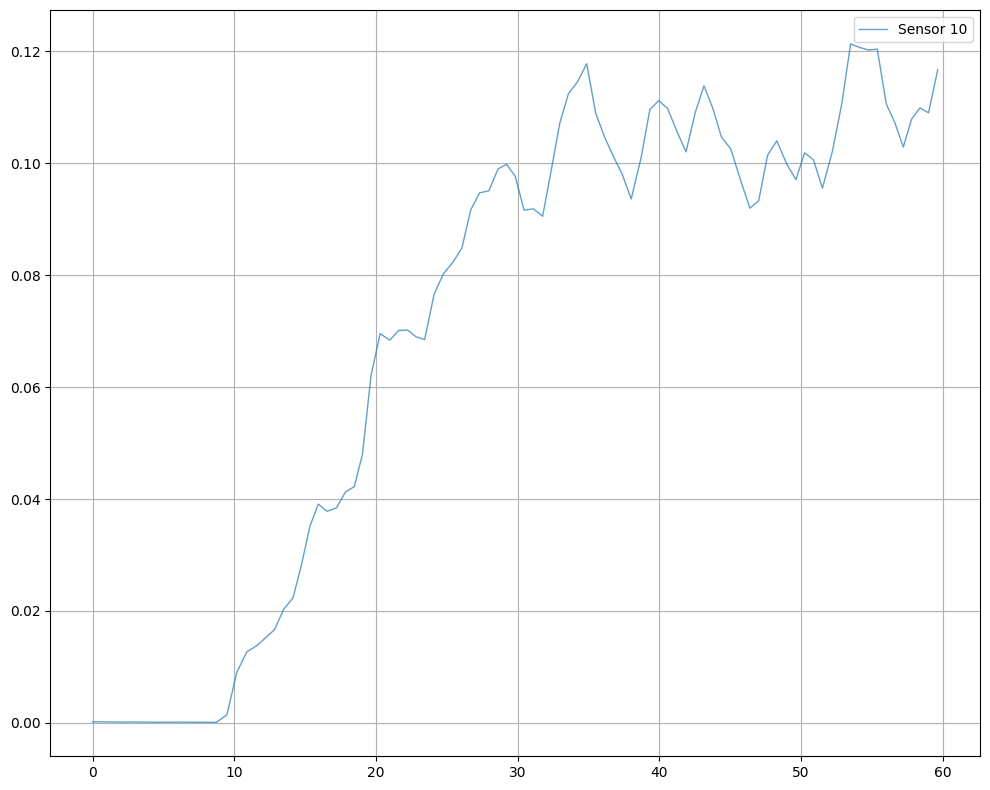

In [52]:
# Plot time series for a few sensors
sensor_ids = [10, 11]
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

for idx, sensor_id in enumerate(sensor_ids):
    
    # Experimental data (reality gap)
    df_exp_sensor = df[(df['experiment_id'] == '23_FFI_P101_T00007') &
                       (df['sensor_id'] == sensor_id)]
    if len(df_exp_sensor) > 0:
        ax.plot(df_exp_sensor['time'], df_exp_sensor['h2_volume_fraction'], 
                label=f'Sensor {int(sensor_id)}', alpha=0.7, linewidth=1)
    
    ax.legend()
plt.grid()
plt.tight_layout()
plt.show()

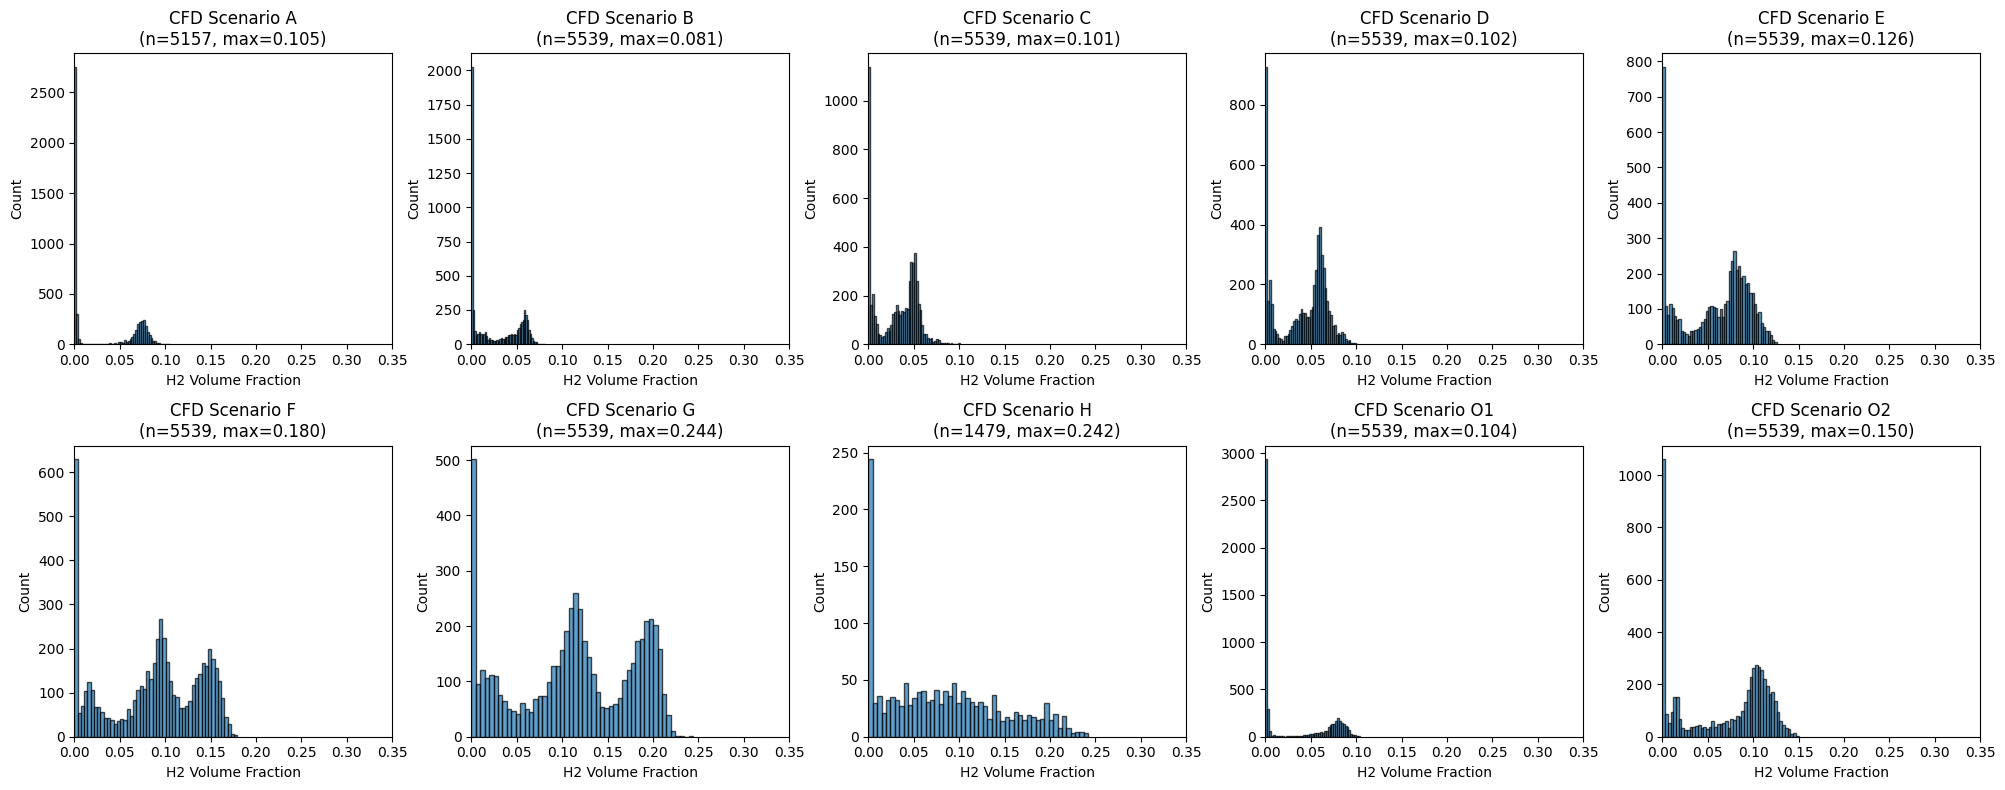

In [3]:
# CFD scenario histograms
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

cfd_scenarios = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'O1', 'O2']

for idx, scenario in enumerate(cfd_scenarios):
    ax = axes[idx]
    df_scenario = df[(df['source'] == 'cfd') & (df['scenario'] == scenario)]
    
    ax.hist(df_scenario['h2_volume_fraction'], bins=50, alpha=0.7, edgecolor='black')
    ax.set_title(f'CFD Scenario {scenario}\n(n={len(df_scenario)}, max={df_scenario["h2_volume_fraction"].max():.3f})')
    ax.set_xlabel('H2 Volume Fraction')
    ax.set_ylabel('Count')
    ax.set_xlim(0, 0.35)

plt.tight_layout()
plt.savefig(data_dir / 'cfd_histograms.png', dpi=150)
plt.show()

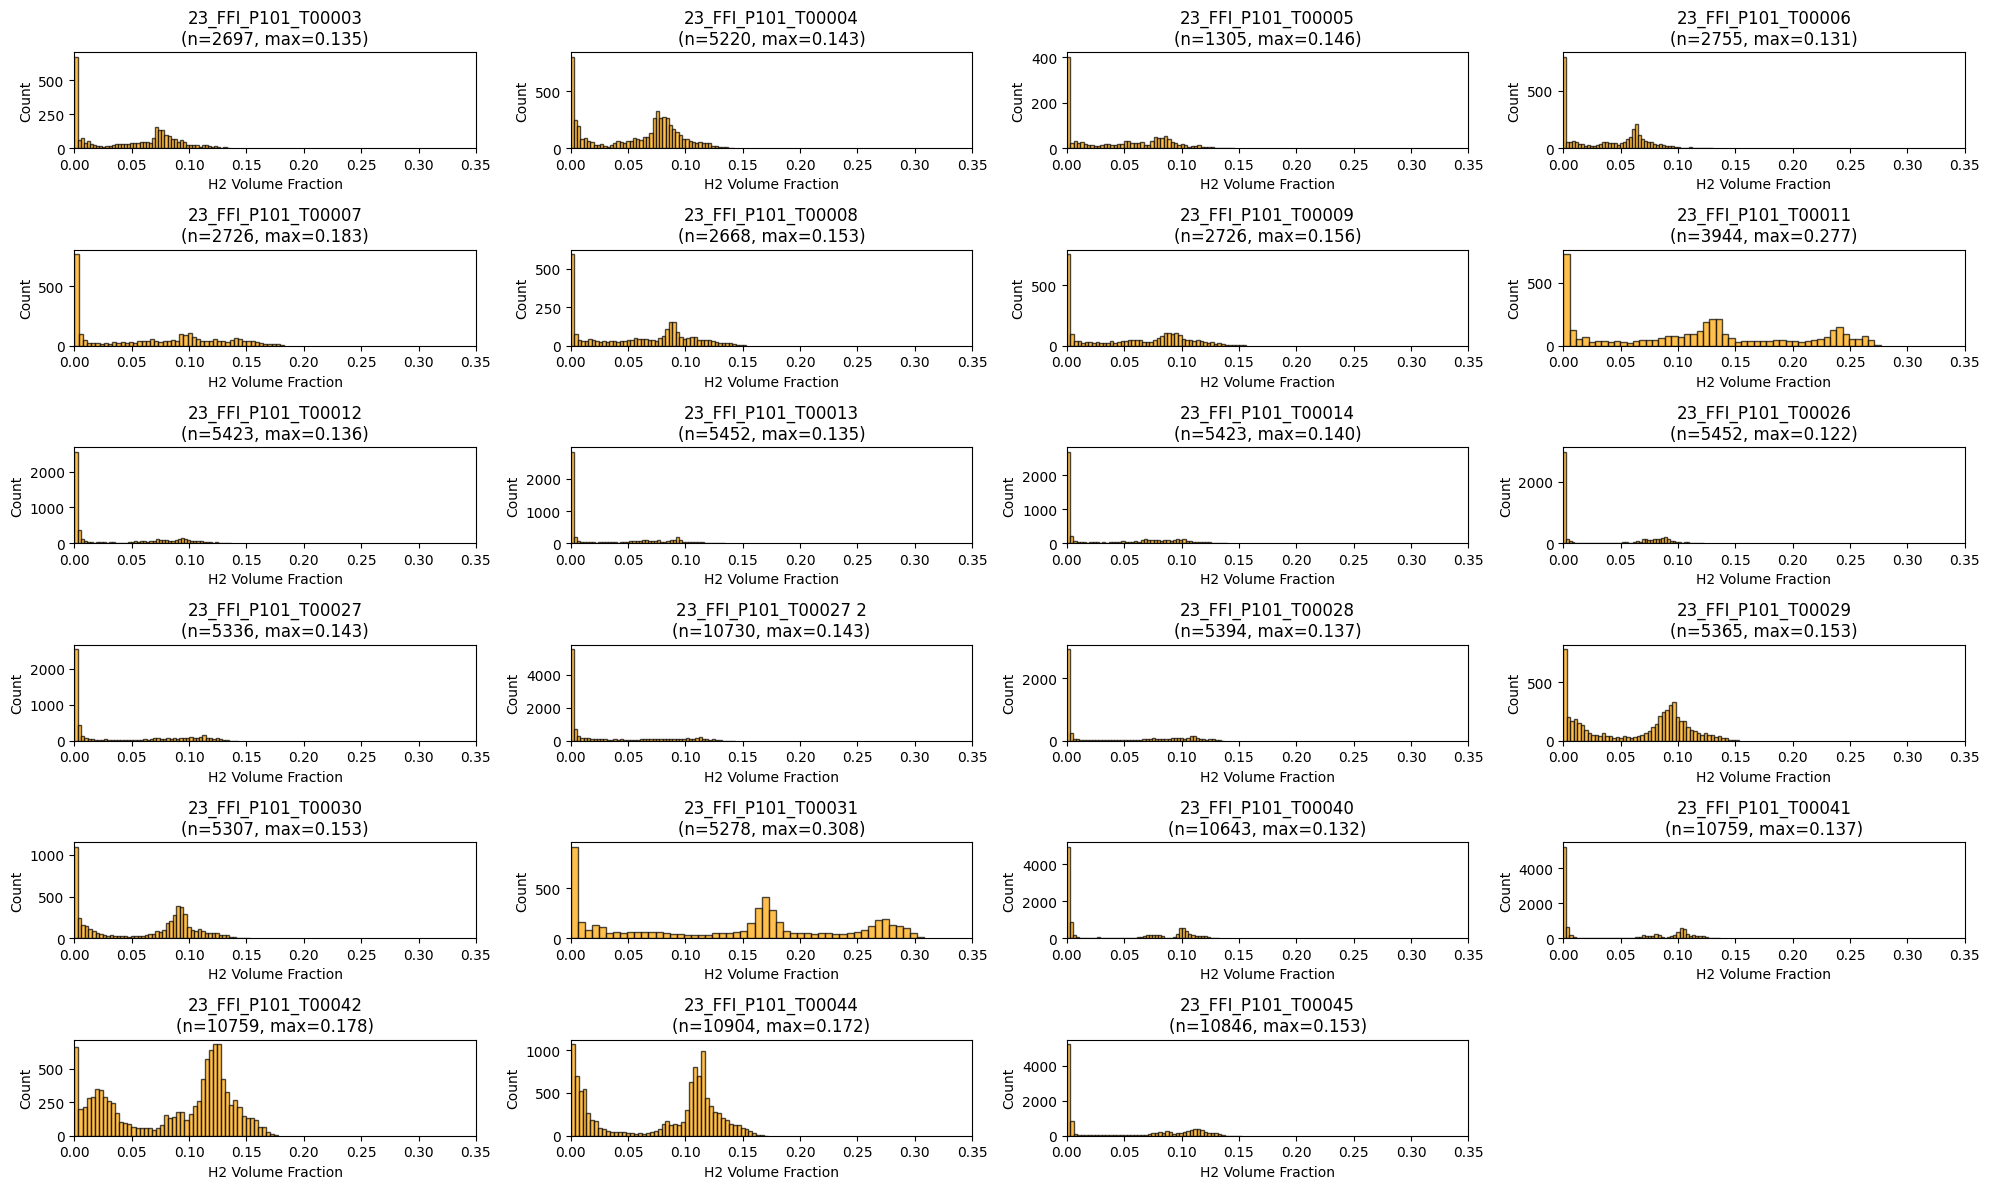

In [11]:
# Experiment histograms (all 23)
exp_ids = df[df['source'] == 'experiment']['experiment_id'].unique()

fig, axes = plt.subplots(6, 4, figsize=(20, 12))
axes = axes.flatten()

for idx, exp_id in enumerate(exp_ids):
    ax = axes[idx]
    df_exp = df[df['experiment_id'] == exp_id]
    
    ax.hist(df_exp['h2_volume_fraction'], bins=50, alpha=0.7, edgecolor='black', color='orange')
    ax.set_title(f'{exp_id}\n(n={len(df_exp)}, max={df_exp["h2_volume_fraction"].max():.3f})')
    ax.set_xlabel('H2 Volume Fraction')
    ax.set_ylabel('Count')
    ax.set_xlim(0, 0.35)

# Remove the last (24th) empty subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig(data_dir / 'experiment_histograms.png', dpi=150)
plt.show()

Correlation Matrix (Features + H2 Volume Fraction):
                    mass_flow   time      x      y      z  h2_volume_fraction
mass_flow               1.000 -0.192  0.002 -0.001  0.001               0.450
time                   -0.192  1.000  0.001 -0.000  0.000               0.126
x                       0.002  0.001  1.000  0.006  0.033              -0.029
y                      -0.001 -0.000  0.006  1.000  0.135              -0.277
z                       0.001  0.000  0.033  0.135  1.000               0.376
h2_volume_fraction      0.450  0.126 -0.029 -0.277  0.376               1.000

Correlations with H2 Volume Fraction (sorted by absolute value):
  mass_flow      : +0.4502
  z              : +0.3764
  y              : -0.2771
  time           : +0.1264
  x              : -0.0291


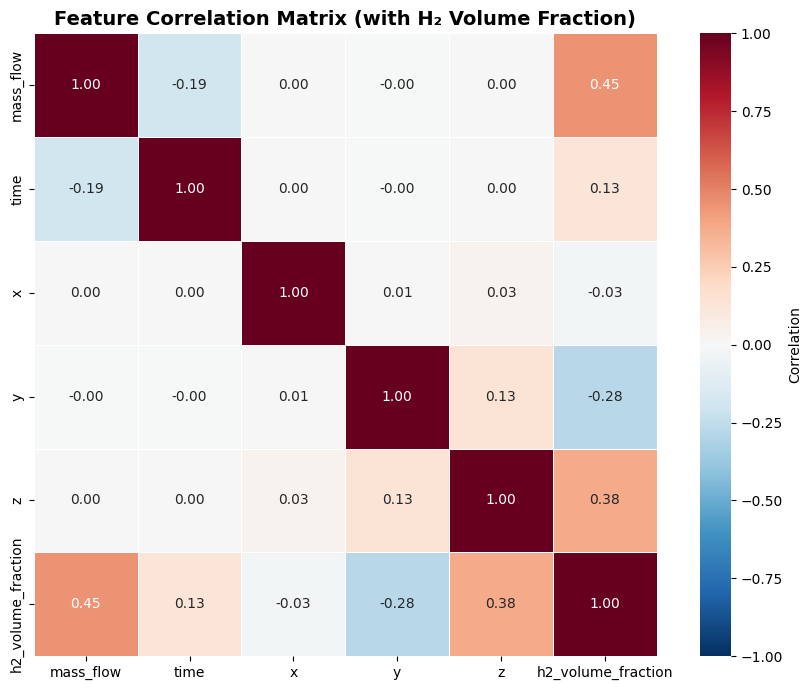

In [10]:
# Select features + target for correlation
features_and_target = ['mass_flow', 'time', 'x', 'y', 'z', 'h2_volume_fraction']
df_features = df[features_and_target]

# Calculate correlation matrix
corr_matrix = df_features.corr()

# Print correlation matrix
print("Correlation Matrix (Features + H2 Volume Fraction):")
print(corr_matrix.round(3))

# Print target correlations sorted by absolute value
target_corr = corr_matrix['h2_volume_fraction'].drop('h2_volume_fraction')
print("\nCorrelations with H2 Volume Fraction (sorted by absolute value):")
for feature, corr in target_corr.reindex(target_corr.abs().sort_values(ascending=False).index).items():
    print(f"  {feature:15s}: {corr:+.4f}")

# Create heatmap
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, 
            annot=True,           # Show correlation values
            fmt='.2f',            # 2 decimal places
            cmap='RdBu_r',        # Red-Blue diverging colormap
            center=0,             # Center at 0
            vmin=-1, vmax=1,      # Correlation range
            square=True,          # Square cells
            linewidths=0.5,       # Grid lines
            cbar_kws={'label': 'Correlation'},
            ax=ax)

ax.set_title('Feature Correlation Matrix (with H₂ Volume Fraction)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix_with_target.png', dpi=150, bbox_inches='tight')
plt.show()

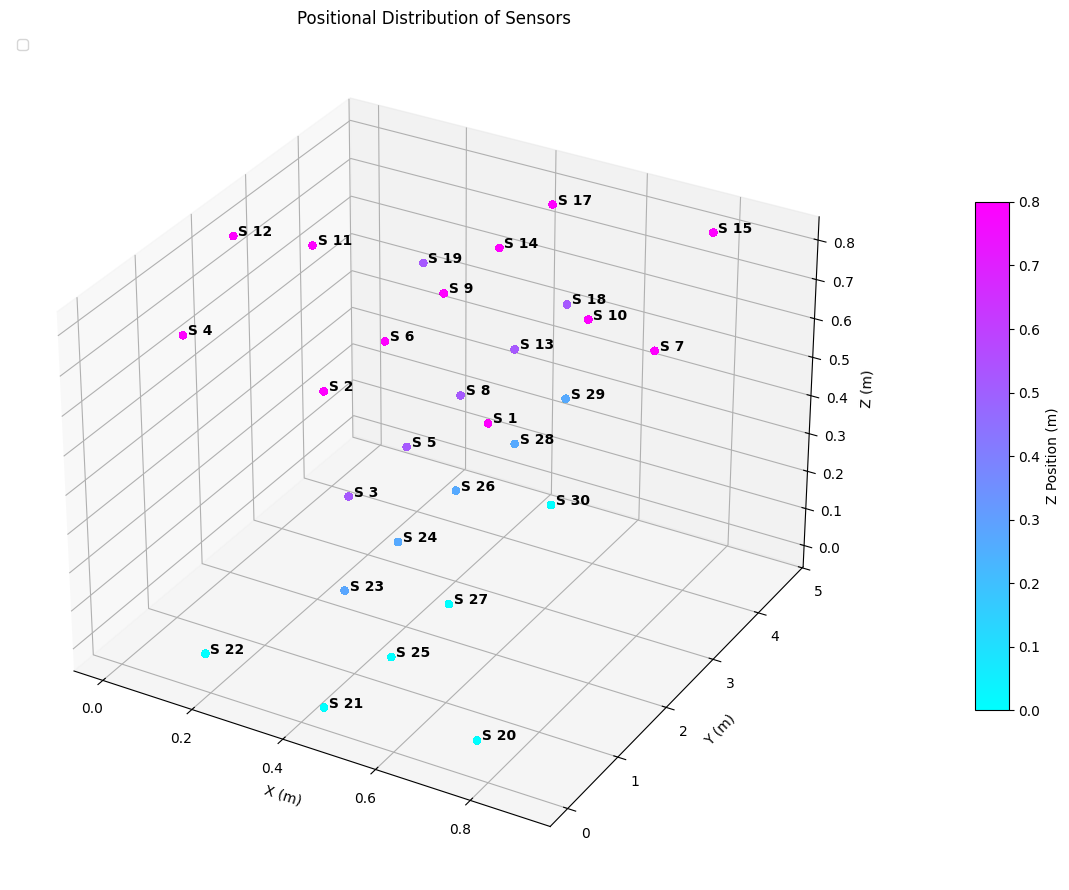

In [34]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Plot all data points colored by Z position
sc = ax.scatter(
    df['x'], 
    df['y'], 
    df['z'],
    c=df['z'],           # color by z-coordinate
    cmap='cool',      # pick a perceptually uniform colormap
    s=30,
    alpha=1.0,
    edgecolors='none'
)

# Overlay sensor positions and annotate with sensor numbers
# SENSOR_POSITIONS = {1: (x1, y1, z1), 2: (x2, y2, z2), ...}
for sensor_id, (sx, sy, sz) in SENSOR_POSITIONS.items():
    ax.text(sx, sy, sz, f' S {sensor_id}', color='black', fontsize=10, fontweight='bold')

# Colorbar for Z position
cbar = plt.colorbar(sc, ax=ax, shrink=0.6, aspect=15, pad=0.1)
cbar.set_label('Z Position (m)')

# Labels
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('Positional Distribution of Sensors')

# Only show one legend entry for sensors
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper left')

plt.tight_layout()
plt.show()

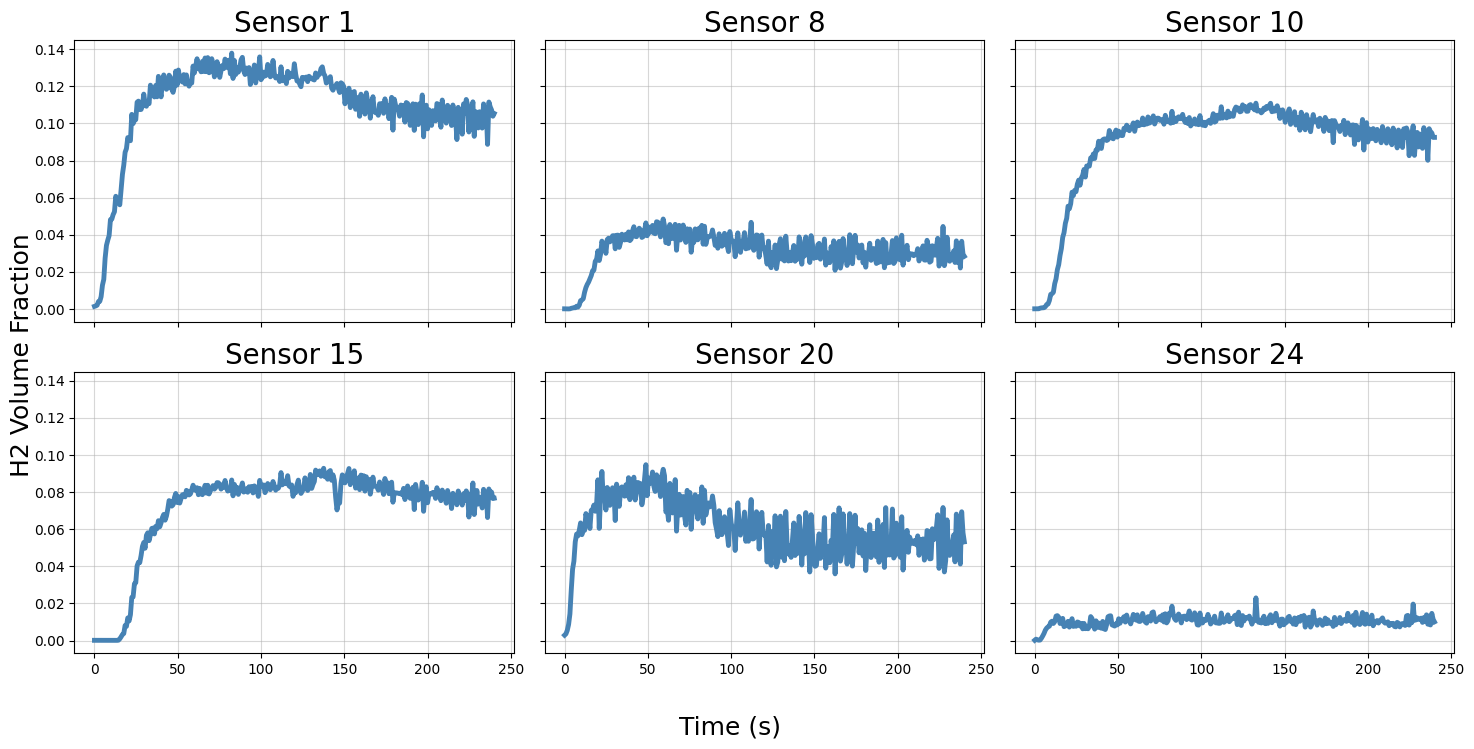

In [8]:
import matplotlib.pyplot as plt

sensor_ids = [1, 8, 10, 15, 20, 24]  # change to your 6 sensors
time_bin = 0.8

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, sensor_id in zip(axes, sensor_ids):
    df_sensor = df[df['sensor_id'] == sensor_id].copy()
    df_sensor['time_rounded'] = (df_sensor['time'] / time_bin).round() * time_bin

    for source, color in [('experiment', 'steelblue'), ('CFD', 'darkorange')]:
        df_src = df_sensor[df_sensor['source'] == source]
        if df_src.empty:
            continue

        grouped = df_src.groupby('time_rounded')['h2_volume_fraction']
        mean = grouped.mean()

        ax.plot(mean.index, mean.values, color=color, linewidth=3.5, label=source.capitalize())

    ax.set_title(f'Sensor {sensor_id}', fontsize=20)
    ax.grid(True, alpha=0.5)

# Global labels
fig.supxlabel('Time (s)', y=0.02, fontsize=18)
fig.supylabel('H2 Volume Fraction', x=0.02, fontsize=18)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

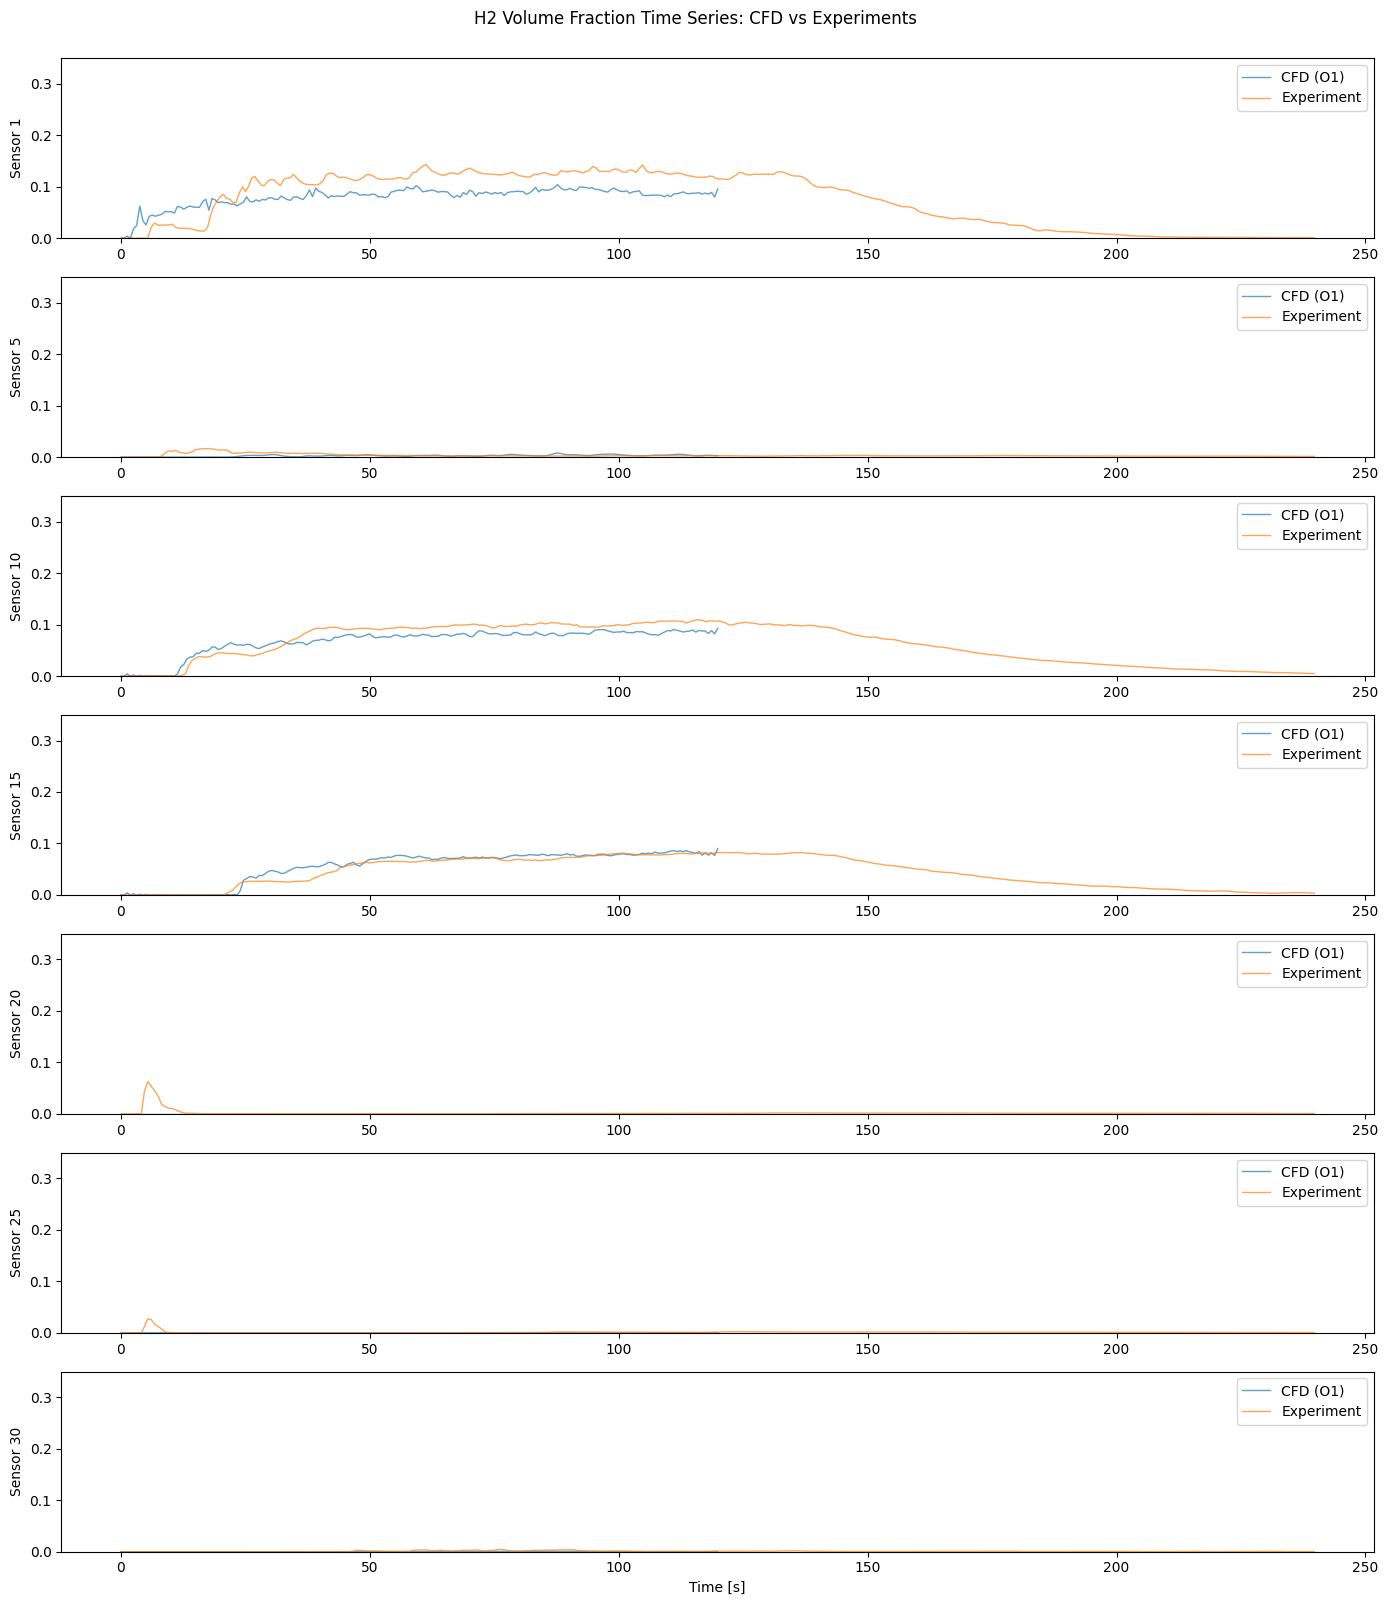

In [81]:
# Plot time series for a few sensors
sensor_ids = [1, 5, 10, 15, 20, 25, 30]
fig, axes = plt.subplots(len(sensor_ids), 1, figsize=(14, 16))

for idx, sensor_id in enumerate(sensor_ids):
    ax = axes[idx]
    
    # CFD data
    df_cfd_sensor = df[(df['source'] == 'cfd') & (df['scenario'] == 'O1') & 
                       (df['sensor_id'] == sensor_id)]
    if len(df_cfd_sensor) > 0:
        ax.plot(df_cfd_sensor['time'], df_cfd_sensor['h2_volume_fraction'], 
                label='CFD (O1)', alpha=0.7, linewidth=1)
    
    # Experimental data (reality gap)
    df_exp_sensor = df[(df['experiment_id'] == '23_FFI_P101_T00027') &
                       (df['sensor_id'] == sensor_id)]
    if len(df_exp_sensor) > 0:
        ax.plot(df_exp_sensor['time'], df_exp_sensor['h2_volume_fraction'], 
                label='Experiment', alpha=0.7, linewidth=1)
    
    ax.set_ylabel(f'Sensor {int(sensor_id)}')
    ax.legend()
    ax.set_ylim(0, 0.35)

axes[-1].set_xlabel('Time [s]')
plt.suptitle('H2 Volume Fraction Time Series: CFD vs Experiments', y=1.0)
plt.tight_layout()
plt.savefig(data_dir / 'time_series_comparison_scenario_O1.png', dpi=150)
plt.show()

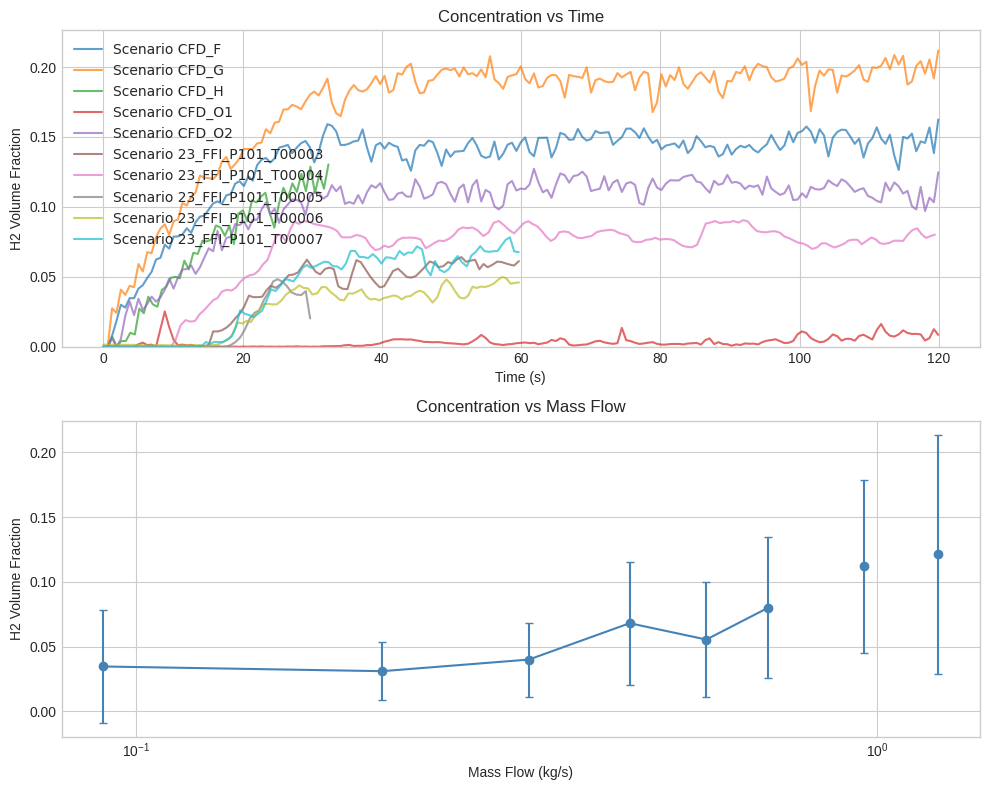


=== DATA SUMMARY ===
Total records: 188,060
Scenarios: 33
Sensors: 29
Time range: [0.0, 239.9] s
Mass flow range: [0.029, 1.270] kg/s
H2 concentration range: [0.0000, 0.3083]


In [10]:
# Set style
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
# Fix font for H2 subscript
plt.rcParams['font.family'] = 'DejaVu Sans'
# 1. Concentration over Time
ax1 = axes[0]
for scenario in df['experiment_id'].unique()[5:15]:  # Plot first 5 scenarios
    df_scen = df[df['experiment_id'] == scenario]
    # Sample one sensor per scenario
    sensor = df_scen['sensor_id'].iloc[400]
    df_sensor = df_scen[df_scen['sensor_id'] == sensor]
    ax1.plot(df_sensor['time'], df_sensor['h2_volume_fraction'], 
             label=f'Scenario {scenario}', alpha=0.7)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('H2 Volume Fraction')  # Fixed: no subscript
ax1.set_title('Concentration vs Time')
ax1.legend()
ax1.set_ylim(0, df['h2_volume_fraction'].quantile(0.99))


# 3. Concentration over Mass Flow
ax3 = axes[1]
# Bin mass flow for cleaner visualization
df['mass_flow_bin'] = pd.cut(df['mass_flow'], bins=10)
massflow_conc = df.groupby('mass_flow_bin', observed=False)['h2_volume_fraction'].agg(['mean', 'std'])
massflow_centers = [interval.mid for interval in massflow_conc.index]
ax3.errorbar(massflow_centers, massflow_conc['mean'], yerr=massflow_conc['std'],
            fmt='o-', capsize=3, color='steelblue')
ax3.set_xlabel('Mass Flow (kg/s)')
ax3.set_ylabel('H2 Volume Fraction')
ax3.set_title('Concentration vs Mass Flow')
ax3.set_xscale('log')

plt.tight_layout()
plt.savefig('data_analysis_overview.png', dpi=150, bbox_inches='tight')
plt.show()
# Summary statistics
print("\n=== DATA SUMMARY ===")
print(f"Total records: {len(df):,}")
print(f"Scenarios: {df['scenario'].nunique()}")
print(f"Sensors: {df['sensor_id'].nunique()}")
print(f"Time range: [{df['time'].min():.1f}, {df['time'].max():.1f}] s")
print(f"Mass flow range: [{df['mass_flow'].min():.3f}, {df['mass_flow'].max():.3f}] kg/s")
print(f"H2 concentration range: [{df['h2_volume_fraction'].min():.4f}, {df['h2_volume_fraction'].max():.4f}]")

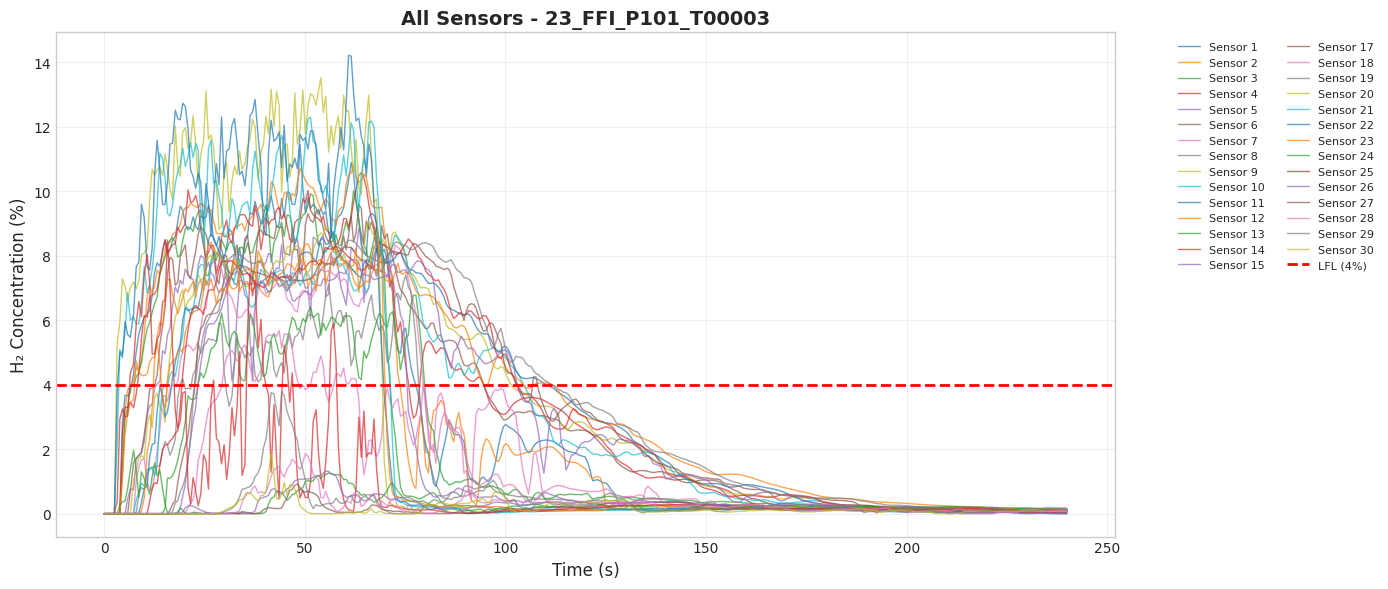

In [56]:
df = pd.read_csv('data/unified_raw.csv')
experiment_id = '23_FFI_P101_T00003'
df_exp = df[df['experiment_id'] == experiment_id]

plt.figure(figsize=(14, 6))

# Plot each sensor with different color
for sensor_id in sorted(df_exp['sensor_id'].unique()):
    sensor_data = df_exp[df_exp['sensor_id'] == sensor_id]
    plt.plot(sensor_data['time'], 
             sensor_data['h2_volume_fraction'] * 100,
             label=f'Sensor {sensor_id}',
             alpha=0.7,
             linewidth=1)

plt.axhline(y=4, color='red', linestyle='--', linewidth=2, label='LFL (4%)')
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('H₂ Concentration (%)', fontsize=12)
plt.title(f'All Sensors - {experiment_id}', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('all_sensors_combined.png', dpi=150, bbox_inches='tight')
plt.show()

Top (x,y) positions with multiple sensors:
  1. X≈0.6m, Y≈1.2m: 4 sensors, mass flows: [0.086      0.15       0.2        0.3        0.48       0.74
 1.         1.27       0.091      0.45       0.47577286 0.47833271
 0.46974408 0.32839189 0.72139255 0.56787114 0.5708861  1.2498731
 0.0792133  0.07918156 0.02917656 0.10135085 0.0879138  0.08578524
 0.4343846  0.43661481 1.22682068 0.09895282 0.09542988 0.48440685
 0.45314028 0.09271138]
  2. X≈0.6m, Y≈4.5m: 4 sensors, mass flows: [0.086      0.15       0.2        0.3        0.48       0.74
 1.         1.27       0.091      0.45       0.47577286 0.47833271
 0.46974408 0.32839189 0.72139255 0.56787114 0.5708861  1.2498731
 0.0792133  0.07918156 0.02917656 0.10135085 0.0879138  0.08578524
 0.4343846  0.43661481 1.22682068 0.09895282 0.09542988 0.48440685
 0.45314028 0.09271138]
  3. X≈0.6m, Y≈2.4m: 3 sensors, mass flows: [0.086      0.15       0.2        0.3        0.48       0.74
 1.         1.27       0.091      0.45       0.47577286 0.47

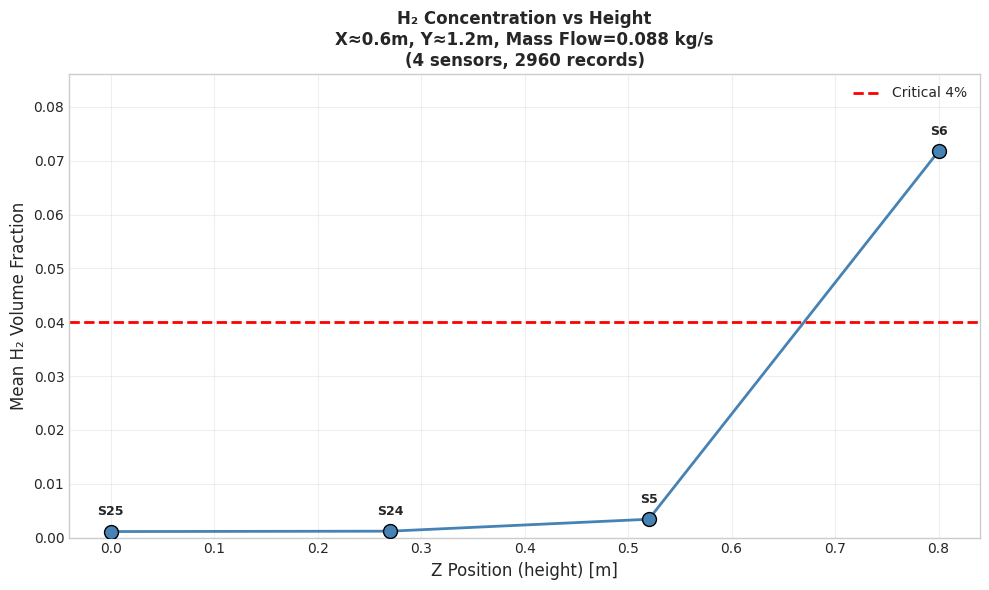


Plot saved!
Z range: 0.00m to 0.80m
Concentration range: 0.0011 to 0.0718

Sensor details:
   sensor_id     x     y     z      conc  n_records
3         25  0.47  1.10  0.00  0.001120        740
2         24  0.46  1.33  0.27  0.001189        740
0          5  0.48  1.33  0.52  0.003406        740
1          6  0.46  1.11  0.80  0.071763        740


In [87]:
# Load data
df = pd.read_csv('data/unified_raw.csv')

# Get unique sensor positions
sensor_pos = df[['sensor_id', 'x', 'y', 'z']].drop_duplicates().set_index('sensor_id')

# TOLERANCE for grouping nearby sensors (in meters)
TOLERANCE = 0.3

# Round x and y to group nearby positions
sensor_pos['x_rounded'] = (sensor_pos['x'] / TOLERANCE).round() * TOLERANCE
sensor_pos['y_rounded'] = (sensor_pos['y'] / TOLERANCE).round() * TOLERANCE

# Find (x, y) groups with multiple sensors and multiple mass flows
sensor_pos['xy_pair'] = list(zip(sensor_pos['x_rounded'], sensor_pos['y_rounded']))

# Check which (x,y) positions have data with consistent mass flows
xy_groups = []
for xy_pair in sensor_pos['xy_pair'].unique():
    mask = (sensor_pos['x_rounded'] == xy_pair[0]) & (sensor_pos['y_rounded'] == xy_pair[1])
    sensors = sensor_pos[mask].index.tolist()
    
    # Get mass flows for these sensors
    mass_flows = df[df['sensor_id'].isin(sensors)]['mass_flow'].unique()
    
    if len(sensors) > 1 and len(mass_flows) > 0:
        xy_groups.append({
            'xy': xy_pair,
            'sensors': sensors,
            'n_sensors': len(sensors),
            'mass_flows': mass_flows,
            'n_mass_flows': len(mass_flows)
        })

# Sort by number of sensors (descending)
xy_groups = sorted(xy_groups, key=lambda x: x['n_sensors'], reverse=True)

print(f"Top (x,y) positions with multiple sensors:")
for i, group in enumerate(xy_groups[:5]):
    print(f"  {i+1}. X≈{group['xy'][0]}m, Y≈{group['xy'][1]}m: "
          f"{group['n_sensors']} sensors, mass flows: {group['mass_flows']}")

# Choose the best group (most sensors with available mass flow data)
chosen_group = xy_groups[0]
fixed_x_rounded, fixed_y_rounded = chosen_group['xy']
sensors_at_xy = chosen_group['sensors']

print(f"\nChosen position: X≈{fixed_x_rounded}m, Y≈{fixed_y_rounded}m")
print(f"Available mass flows: {chosen_group['mass_flows']}")

# Choose the most common mass flow for this position
mass_flow_counts = df[df['sensor_id'].isin(sensors_at_xy)]['mass_flow'].value_counts()
chosen_mass_flow = mass_flow_counts.index[0]

print(f"Selected mass flow: {chosen_mass_flow:.3f} kg/s (most common, {mass_flow_counts.iloc[0]} records)")

# Filter data: same (x,y) tolerance AND same mass flow
filtered_df = df[
    (df['sensor_id'].isin(sensors_at_xy)) &
    (df['mass_flow'] == chosen_mass_flow)
]

print(f"\nFiltered data: {len(filtered_df)} records")

# Calculate mean concentration per sensor at this (x,y) and mass flow
plot_data = []
for sensor_id in sensors_at_xy:
    sensor_data = filtered_df[filtered_df['sensor_id'] == sensor_id]
    if len(sensor_data) > 0:
        mean_conc = sensor_data['h2_volume_fraction'].mean()
        z_pos = sensor_pos.loc[sensor_id, 'z']
        x_pos = sensor_pos.loc[sensor_id, 'x']
        y_pos = sensor_pos.loc[sensor_id, 'y']
        plot_data.append({
            'sensor_id': sensor_id, 
            'x': x_pos, 
            'y': y_pos, 
            'z': z_pos, 
            'conc': mean_conc,
            'n_records': len(sensor_data)
        })

plot_df = pd.DataFrame(plot_data).sort_values('z')

if len(plot_df) == 0:
    print("ERROR: No data found after filtering!")
else:
    # Create plot
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot concentration vs z
    ax.plot(plot_df['z'], plot_df['conc'], 'o-', color='steelblue', 
            linewidth=2, markersize=10, markeredgecolor='black', zorder=3)

    # Add sensor ID labels
    for _, row in plot_df.iterrows():
        ax.annotate(f"S{int(row['sensor_id'])}", 
                   (row['z'], row['conc']),
                   textcoords="offset points",
                   xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')

    # Critical threshold line (4% = 0.04)
    ax.axhline(y=0.04, color='red', linestyle='--', linewidth=2, label='Critical 4%', zorder=1)

    # Formatting
    ax.set_xlabel('Z Position (height) [m]', fontsize=12)
    ax.set_ylabel('Mean H₂ Volume Fraction', fontsize=12)
    ax.set_title(f'H₂ Concentration vs Height\nX≈{fixed_x_rounded}m, Y≈{fixed_y_rounded}m, Mass Flow={chosen_mass_flow:.3f} kg/s\n({len(plot_df)} sensors, {len(filtered_df)} records)', 
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, zorder=0)
    ax.legend(loc='best')

    # Set y-axis limits
    y_max = max(plot_df['conc'].max() * 1.2, 0.05)
    ax.set_ylim(0, y_max)

    plt.tight_layout()
    plt.savefig('concentration_vs_z_fixed_xy_massflow.png', dpi=150)
    plt.show()

    print(f"\nPlot saved!")
    print(f"Z range: {plot_df['z'].min():.2f}m to {plot_df['z'].max():.2f}m")
    print(f"Concentration range: {plot_df['conc'].min():.4f} to {plot_df['conc'].max():.4f}")
    print(f"\nSensor details:")
    print(plot_df[['sensor_id', 'x', 'y', 'z', 'conc', 'n_records']])

Available (x,z) positions with multiple Y sensors:
  1. X≈0.44999999999999996m, Z≈0.75m: 5 sensors, mass flows: ['0.086', '0.150', '0.200', '0.300', '0.480', '0.740', '1.000', '1.270', '0.091', '0.450', '0.476', '0.478', '0.470', '0.328', '0.721', '0.568', '0.571', '1.250', '0.079', '0.079', '0.029', '0.101', '0.088', '0.086', '0.434', '0.437', '1.227', '0.099', '0.095', '0.484', '0.453', '0.093']
  2. X≈0.44999999999999996m, Z≈0.44999999999999996m: 5 sensors, mass flows: ['0.086', '0.150', '0.200', '0.300', '0.480', '0.740', '1.000', '1.270', '0.091', '0.450', '0.476', '0.478', '0.470', '0.328', '0.721', '0.568', '0.571', '1.250', '0.079', '0.079', '0.029', '0.101', '0.088', '0.086', '0.434', '0.437', '1.227', '0.099', '0.095', '0.484', '0.453', '0.093']
  3. X≈0.44999999999999996m, Z≈0.3m: 5 sensors, mass flows: ['0.086', '0.150', '0.200', '0.300', '0.480', '0.740', '1.000', '1.270', '0.091', '0.450', '0.476', '0.478', '0.470', '0.328', '0.721', '0.568', '0.571', '1.250', '0.079', '0

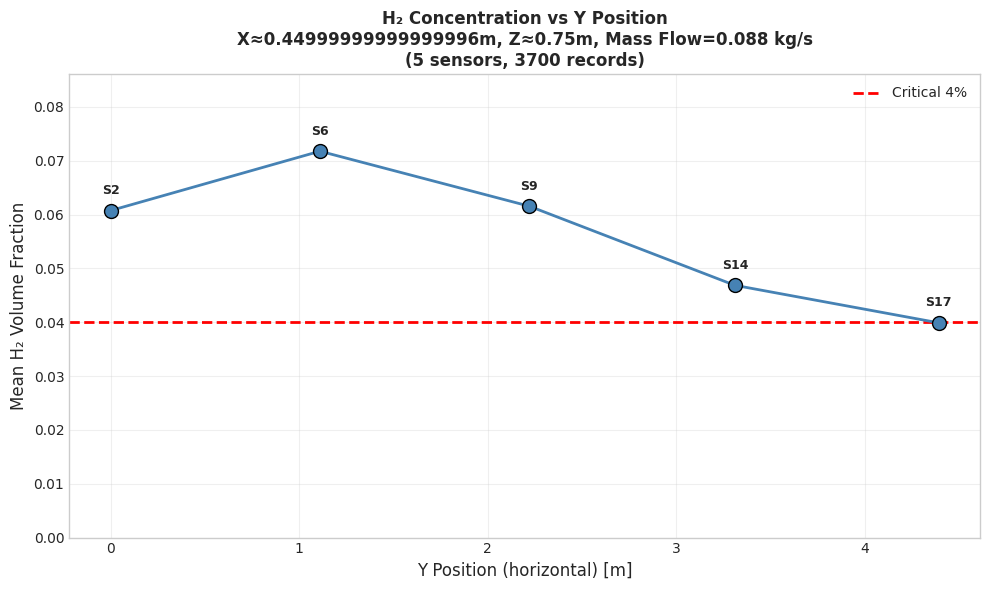


Plot saved!
Y range: 0.00m to 4.39m
Concentration range: 0.0399 to 0.0718

Sensor details:
   sensor_id     x     y    z      conc  n_records
0          2  0.46  0.00  0.8  0.060735        740
1          6  0.46  1.11  0.8  0.071763        740
2          9  0.46  2.22  0.8  0.061552        740
3         14  0.46  3.31  0.8  0.046855        740
4         17  0.46  4.39  0.8  0.039891        740


In [88]:
# Load data
df = pd.read_csv('data/unified_raw.csv')

# Get unique sensor positions
sensor_pos = df[['sensor_id', 'x', 'y', 'z']].drop_duplicates().set_index('sensor_id')

# TOLERANCE for grouping nearby sensors (in meters)
TOLERANCE = 0.15

# Round x and z to group nearby positions (we want to fix X and Z, vary Y)
sensor_pos['x_rounded'] = (sensor_pos['x'] / TOLERANCE).round() * TOLERANCE
sensor_pos['z_rounded'] = (sensor_pos['z'] / TOLERANCE).round() * TOLERANCE

# Find (x, z) groups that have multiple sensors (different y values)
sensor_pos['xz_pair'] = list(zip(sensor_pos['x_rounded'], sensor_pos['z_rounded']))

# Check which (x,z) positions have data with consistent mass flows
xz_groups = []
for xz_pair in sensor_pos['xz_pair'].unique():
    mask = (sensor_pos['x_rounded'] == xz_pair[0]) & (sensor_pos['z_rounded'] == xz_pair[1])
    sensors = sensor_pos[mask].index.tolist()
    
    # Get mass flows for these sensors
    mass_flows = df[df['sensor_id'].isin(sensors)]['mass_flow'].unique()
    
    if len(sensors) > 1 and len(mass_flows) > 0:
        xz_groups.append({
            'xz': xz_pair,
            'sensors': sensors,
            'n_sensors': len(sensors),
            'mass_flows': mass_flows,
            'n_mass_flows': len(mass_flows)
        })

# Sort by number of sensors (descending)
xz_groups = sorted(xz_groups, key=lambda x: x['n_sensors'], reverse=True)

print(f"Available (x,z) positions with multiple Y sensors:")
for i, group in enumerate(xz_groups[:5]):
    print(f"  {i+1}. X≈{group['xz'][0]}m, Z≈{group['xz'][1]}m: "
          f"{group['n_sensors']} sensors, mass flows: {[f'{mf:.3f}' for mf in group['mass_flows']]}")

if len(xz_groups) == 0:
    print("No (x,z) positions found with multiple Y sensors!")
    print("Try increasing TOLERANCE or check data...")
else:
    # Choose the best group
    chosen_group = xz_groups[0]
    fixed_x_rounded, fixed_z_rounded = chosen_group['xz']
    sensors_at_xz = chosen_group['sensors']

    print(f"\nChosen position: X≈{fixed_x_rounded}m, Z≈{fixed_z_rounded}m")
    print(f"Available mass flows: {[f'{mf:.3f}' for mf in chosen_group['mass_flows']]}")

    # Choose the most common mass flow
    mass_flow_counts = df[df['sensor_id'].isin(sensors_at_xz)]['mass_flow'].value_counts()
    chosen_mass_flow = mass_flow_counts.index[0]

    print(f"Selected mass flow: {chosen_mass_flow:.3f} kg/s (most common, {mass_flow_counts.iloc[0]} records)")

    # Filter data: same (x,z) tolerance AND same mass flow
    filtered_df = df[
        (df['sensor_id'].isin(sensors_at_xz)) &
        (df['mass_flow'] == chosen_mass_flow)
    ]

    print(f"\nFiltered data: {len(filtered_df)} records")

    # Calculate mean concentration per sensor
    plot_data = []
    for sensor_id in sensors_at_xz:
        sensor_data = filtered_df[filtered_df['sensor_id'] == sensor_id]
        if len(sensor_data) > 0:
            mean_conc = sensor_data['h2_volume_fraction'].mean()
            y_pos = sensor_pos.loc[sensor_id, 'y']
            x_pos = sensor_pos.loc[sensor_id, 'x']
            z_pos = sensor_pos.loc[sensor_id, 'z']
            plot_data.append({
                'sensor_id': sensor_id, 
                'x': x_pos, 
                'y': y_pos, 
                'z': z_pos, 
                'conc': mean_conc,
                'n_records': len(sensor_data)
            })

    plot_df = pd.DataFrame(plot_data).sort_values('y')

    if len(plot_df) == 0:
        print("ERROR: No data found after filtering!")
    else:
        # Create plot
        fig, ax = plt.subplots(figsize=(10, 6))

        # Plot concentration vs Y
        ax.plot(plot_df['y'], plot_df['conc'], 'o-', color='steelblue', 
                linewidth=2, markersize=10, markeredgecolor='black', zorder=3)

        # Add sensor ID labels
        for _, row in plot_df.iterrows():
            ax.annotate(f"S{int(row['sensor_id'])}", 
                       (row['y'], row['conc']),
                       textcoords="offset points",
                       xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')

        # Critical threshold line (4% = 0.04)
        ax.axhline(y=0.04, color='red', linestyle='--', linewidth=2, label='Critical 4%', zorder=1)

        # Formatting
        ax.set_xlabel('Y Position (horizontal) [m]', fontsize=12)
        ax.set_ylabel('Mean H₂ Volume Fraction', fontsize=12)
        ax.set_title(f'H₂ Concentration vs Y Position\nX≈{fixed_x_rounded}m, Z≈{fixed_z_rounded}m, Mass Flow={chosen_mass_flow:.3f} kg/s\n({len(plot_df)} sensors, {len(filtered_df)} records)', 
                     fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, zorder=0)
        ax.legend(loc='best')

        # Set y-axis limits
        y_max = max(plot_df['conc'].max() * 1.2, 0.05)
        ax.set_ylim(0, y_max)

        plt.tight_layout()
        plt.savefig('concentration_vs_y_fixed_xz_massflow.png', dpi=150)
        plt.show()

        print(f"\nPlot saved!")
        print(f"Y range: {plot_df['y'].min():.2f}m to {plot_df['y'].max():.2f}m")
        print(f"Concentration range: {plot_df['conc'].min():.4f} to {plot_df['conc'].max():.4f}")
        print(f"\nSensor details:")
        print(plot_df[['sensor_id', 'x', 'y', 'z', 'conc', 'n_records']])

Available (y,z) positions with multiple X sensors:
  1. Y≈2.25m, Z≈0.75m: 3 sensors, mass flows: ['0.086', '0.150', '0.200', '0.300', '0.480', '0.740', '1.000', '1.270', '0.091', '0.450', '0.476', '0.478', '0.470', '0.328', '0.721', '0.568', '0.571', '1.250', '0.079', '0.079', '0.029', '0.101', '0.088', '0.086', '0.434', '0.437', '1.227', '0.099', '0.095', '0.484', '0.453', '0.093']
  2. Y≈0.3m, Z≈0.75m: 2 sensors, mass flows: ['0.086', '0.150', '0.200', '0.300', '0.480', '0.740', '1.000', '1.270', '0.091', '0.450', '0.476', '0.478', '0.470', '0.328', '0.721', '0.568', '0.571', '1.250', '0.079', '0.079', '0.029', '0.101', '0.088', '0.086', '0.434', '0.437', '1.227', '0.099', '0.095', '0.484', '0.453', '0.093']
  3. Y≈2.4m, Z≈0.75m: 2 sensors, mass flows: ['0.086', '0.150', '0.200', '0.300', '0.480', '0.740', '1.000', '1.270', '0.091', '0.450', '0.476', '0.478', '0.470', '0.328', '0.721', '0.568', '0.571', '1.250', '0.079', '0.079', '0.029', '0.101', '0.088', '0.086', '0.434', '0.437', 

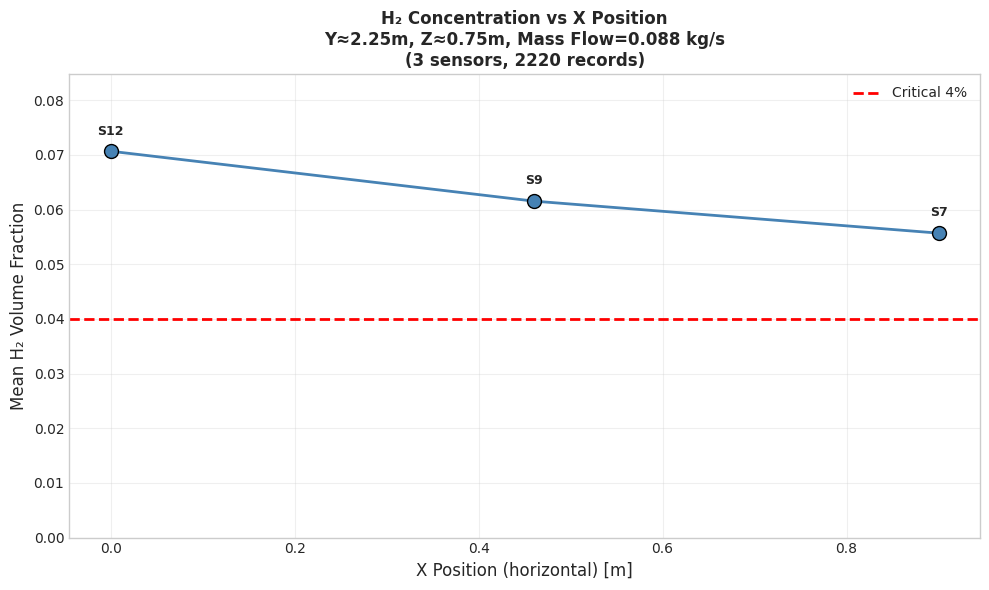


Plot saved!
X range: 0.00m to 0.90m
Concentration range: 0.0557 to 0.0707

Sensor details:
   sensor_id     x     y    z      conc  n_records
1         12  0.00  2.22  0.8  0.070682        740
0          9  0.46  2.22  0.8  0.061552        740
2          7  0.90  2.22  0.8  0.055694        740


In [89]:
# Load data
df = pd.read_csv('data/unified_raw.csv')

# Get unique sensor positions
sensor_pos = df[['sensor_id', 'x', 'y', 'z']].drop_duplicates().set_index('sensor_id')

# TOLERANCE for grouping nearby sensors (in meters)
TOLERANCE = 0.15

# Round y and z to group nearby positions (we want to fix Y and Z, vary X)
sensor_pos['y_rounded'] = (sensor_pos['y'] / TOLERANCE).round() * TOLERANCE
sensor_pos['z_rounded'] = (sensor_pos['z'] / TOLERANCE).round() * TOLERANCE

# Find (y, z) groups that have multiple sensors (different x values)
sensor_pos['yz_pair'] = list(zip(sensor_pos['y_rounded'], sensor_pos['z_rounded']))

# Check which (y,z) positions have data with consistent mass flows
yz_groups = []
for yz_pair in sensor_pos['yz_pair'].unique():
    mask = (sensor_pos['y_rounded'] == yz_pair[0]) & (sensor_pos['z_rounded'] == yz_pair[1])
    sensors = sensor_pos[mask].index.tolist()
    
    # Get mass flows for these sensors
    mass_flows = df[df['sensor_id'].isin(sensors)]['mass_flow'].unique()
    
    if len(sensors) > 1 and len(mass_flows) > 0:
        yz_groups.append({
            'yz': yz_pair,
            'sensors': sensors,
            'n_sensors': len(sensors),
            'mass_flows': mass_flows,
            'n_mass_flows': len(mass_flows)
        })

# Sort by number of sensors (descending)
yz_groups = sorted(yz_groups, key=lambda x: x['n_sensors'], reverse=True)

print(f"Available (y,z) positions with multiple X sensors:")
for i, group in enumerate(yz_groups[:5]):
    print(f"  {i+1}. Y≈{group['yz'][0]}m, Z≈{group['yz'][1]}m: "
          f"{group['n_sensors']} sensors, mass flows: {[f'{mf:.3f}' for mf in group['mass_flows']]}")

if len(yz_groups) == 0:
    print("No (y,z) positions found with multiple X sensors!")
    print("Try increasing TOLERANCE or check data...")
else:
    # Choose the best group
    chosen_group = yz_groups[0]
    fixed_y_rounded, fixed_z_rounded = chosen_group['yz']
    sensors_at_yz = chosen_group['sensors']

    print(f"\nChosen position: Y≈{fixed_y_rounded}m, Z≈{fixed_z_rounded}m")
    print(f"Available mass flows: {[f'{mf:.3f}' for mf in chosen_group['mass_flows']]}")

    # Choose the most common mass flow
    mass_flow_counts = df[df['sensor_id'].isin(sensors_at_yz)]['mass_flow'].value_counts()
    chosen_mass_flow = mass_flow_counts.index[0]

    print(f"Selected mass flow: {chosen_mass_flow:.3f} kg/s (most common, {mass_flow_counts.iloc[0]} records)")

    # Filter data: same (y,z) tolerance AND same mass flow
    filtered_df = df[
        (df['sensor_id'].isin(sensors_at_yz)) &
        (df['mass_flow'] == chosen_mass_flow)
    ]

    print(f"\nFiltered data: {len(filtered_df)} records")

    # Calculate mean concentration per sensor
    plot_data = []
    for sensor_id in sensors_at_yz:
        sensor_data = filtered_df[filtered_df['sensor_id'] == sensor_id]
        if len(sensor_data) > 0:
            mean_conc = sensor_data['h2_volume_fraction'].mean()
            x_pos = sensor_pos.loc[sensor_id, 'x']
            y_pos = sensor_pos.loc[sensor_id, 'y']
            z_pos = sensor_pos.loc[sensor_id, 'z']
            plot_data.append({
                'sensor_id': sensor_id, 
                'x': x_pos, 
                'y': y_pos, 
                'z': z_pos, 
                'conc': mean_conc,
                'n_records': len(sensor_data)
            })

    plot_df = pd.DataFrame(plot_data).sort_values('x')

    if len(plot_df) == 0:
        print("ERROR: No data found after filtering!")
    else:
        # Create plot
        fig, ax = plt.subplots(figsize=(10, 6))

        # Plot concentration vs X
        ax.plot(plot_df['x'], plot_df['conc'], 'o-', color='steelblue', 
                linewidth=2, markersize=10, markeredgecolor='black', zorder=3)

        # Add sensor ID labels
        for _, row in plot_df.iterrows():
            ax.annotate(f"S{int(row['sensor_id'])}", 
                       (row['x'], row['conc']),
                       textcoords="offset points",
                       xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')

        # Critical threshold line (4% = 0.04)
        ax.axhline(y=0.04, color='red', linestyle='--', linewidth=2, label='Critical 4%', zorder=1)

        # Formatting
        ax.set_xlabel('X Position (horizontal) [m]', fontsize=12)
        ax.set_ylabel('Mean H₂ Volume Fraction', fontsize=12)
        ax.set_title(f'H₂ Concentration vs X Position\nY≈{fixed_y_rounded}m, Z≈{fixed_z_rounded}m, Mass Flow={chosen_mass_flow:.3f} kg/s\n({len(plot_df)} sensors, {len(filtered_df)} records)', 
                     fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, zorder=0)
        ax.legend(loc='best')

        # Set y-axis limits
        y_max = max(plot_df['conc'].max() * 1.2, 0.05)
        ax.set_ylim(0, y_max)

        plt.tight_layout()
        plt.savefig('concentration_vs_x_fixed_yz_massflow.png', dpi=150)
        plt.show()

        print(f"\nPlot saved!")
        print(f"X range: {plot_df['x'].min():.2f}m to {plot_df['x'].max():.2f}m")
        print(f"Concentration range: {plot_df['conc'].min():.4f} to {plot_df['conc'].max():.4f}")
        print(f"\nSensor details:")
        print(plot_df[['sensor_id', 'x', 'y', 'z', 'conc', 'n_records']])

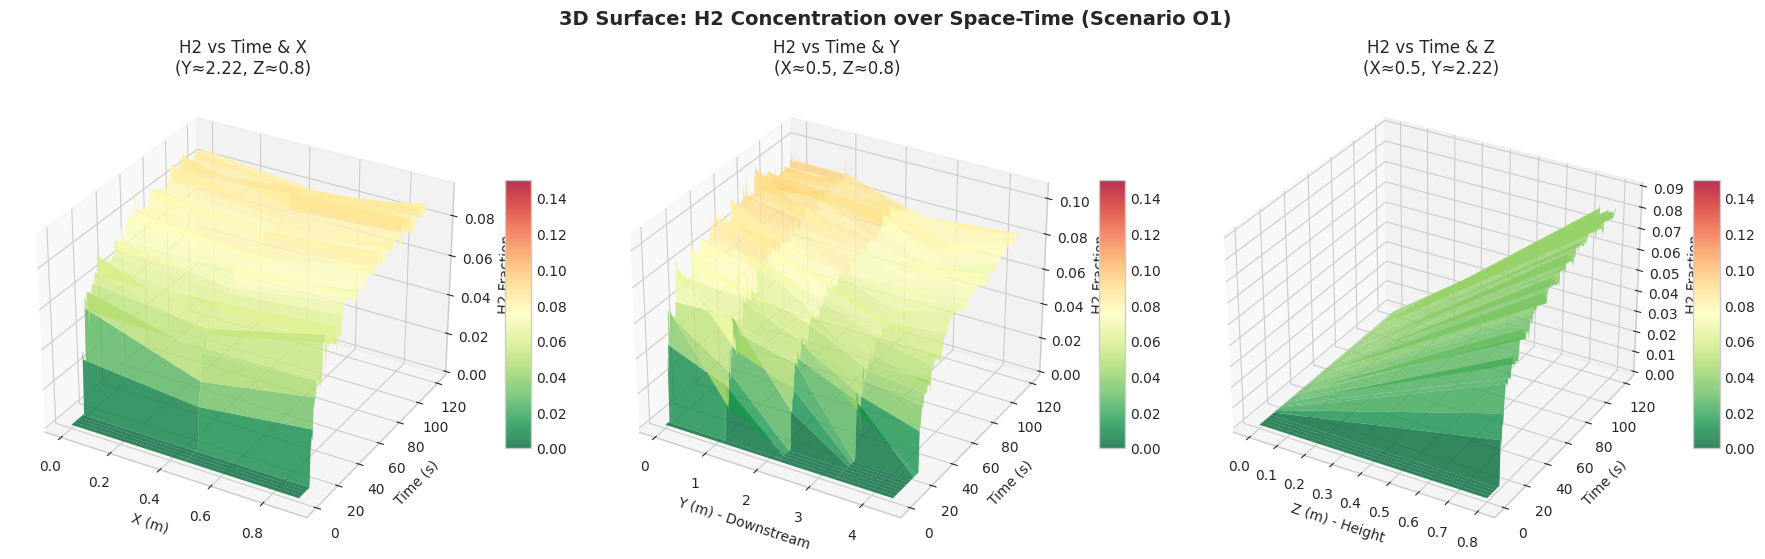

In [65]:
# Select scenario
scenario = 'O1'
df_scen = df[df['scenario'] == scenario]

fig = plt.figure(figsize=(18, 6))

# 1. H2 surface over Time and X
ax1 = fig.add_subplot(131, projection='3d')
y_fix, z_fix = 2.22, 0.8
tol = 0.2

df_tx = df_scen[
    (np.abs(df_scen['y'] - y_fix) < tol) & 
    (np.abs(df_scen['z'] - z_fix) < tol)
]

if len(df_tx) > 0:
    pivot = df_tx.pivot_table(values='h2_volume_fraction', index='time', columns='x', aggfunc='mean')
    X, T = np.meshgrid(pivot.columns.values, pivot.index.values)
    Z = pivot.values
    
    surf1 = ax1.plot_surface(X, T, Z, cmap='RdYlGn_r', alpha=0.8, 
                            vmin=0, vmax=0.15, edgecolor='none')
    ax1.set_xlabel('X (m)')
    ax1.set_ylabel('Time (s)')
    ax1.set_zlabel('H2 Fraction')
    ax1.set_title(f'H2 vs Time & X\n(Y≈{y_fix}, Z≈{z_fix})')
    fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)

# 2. H2 surface over Time and Y
ax2 = fig.add_subplot(132, projection='3d')
x_fix, z_fix = 0.5, 0.8

df_ty = df_scen[
    (np.abs(df_scen['x'] - x_fix) < tol) & 
    (np.abs(df_scen['z'] - z_fix) < tol)
]

if len(df_ty) > 0:
    pivot = df_ty.pivot_table(values='h2_volume_fraction', index='time', columns='y', aggfunc='mean')
    Y, T = np.meshgrid(pivot.columns.values, pivot.index.values)
    Z = pivot.values
    
    surf2 = ax2.plot_surface(Y, T, Z, cmap='RdYlGn_r', alpha=0.8,
                            vmin=0, vmax=0.15, edgecolor='none')
    ax2.set_xlabel('Y (m) - Downstream')
    ax2.set_ylabel('Time (s)')
    ax2.set_zlabel('H2 Fraction')
    ax2.set_title(f'H2 vs Time & Y\n(X≈{x_fix}, Z≈{z_fix})')
    fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)

# 3. H2 surface over Time and Z
ax3 = fig.add_subplot(133, projection='3d')
x_fix, y_fix = 0.5, 2.22

df_tz = df_scen[
    (np.abs(df_scen['x'] - x_fix) < tol) & 
    (np.abs(df_scen['y'] - y_fix) < tol)
]

if len(df_tz) > 0:
    pivot = df_tz.pivot_table(values='h2_volume_fraction', index='time', columns='z', aggfunc='mean')
    Z_pos, T = np.meshgrid(pivot.columns.values, pivot.index.values)
    H2 = pivot.values
    
    surf3 = ax3.plot_surface(Z_pos, T, H2, cmap='RdYlGn_r', alpha=0.8,
                            vmin=0, vmax=0.15, edgecolor='none')
    ax3.set_xlabel('Z (m) - Height')
    ax3.set_ylabel('Time (s)')
    ax3.set_zlabel('H2 Fraction')
    ax3.set_title(f'H2 vs Time & Z\n(X≈{x_fix}, Y≈{y_fix})')
    fig.colorbar(surf3, ax=ax3, shrink=0.5, aspect=10)

plt.suptitle(f'3D Surface: H2 Concentration over Space-Time (Scenario {scenario})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('h2_spacetime_3d_surface.png', dpi=150, bbox_inches='tight')
plt.show()


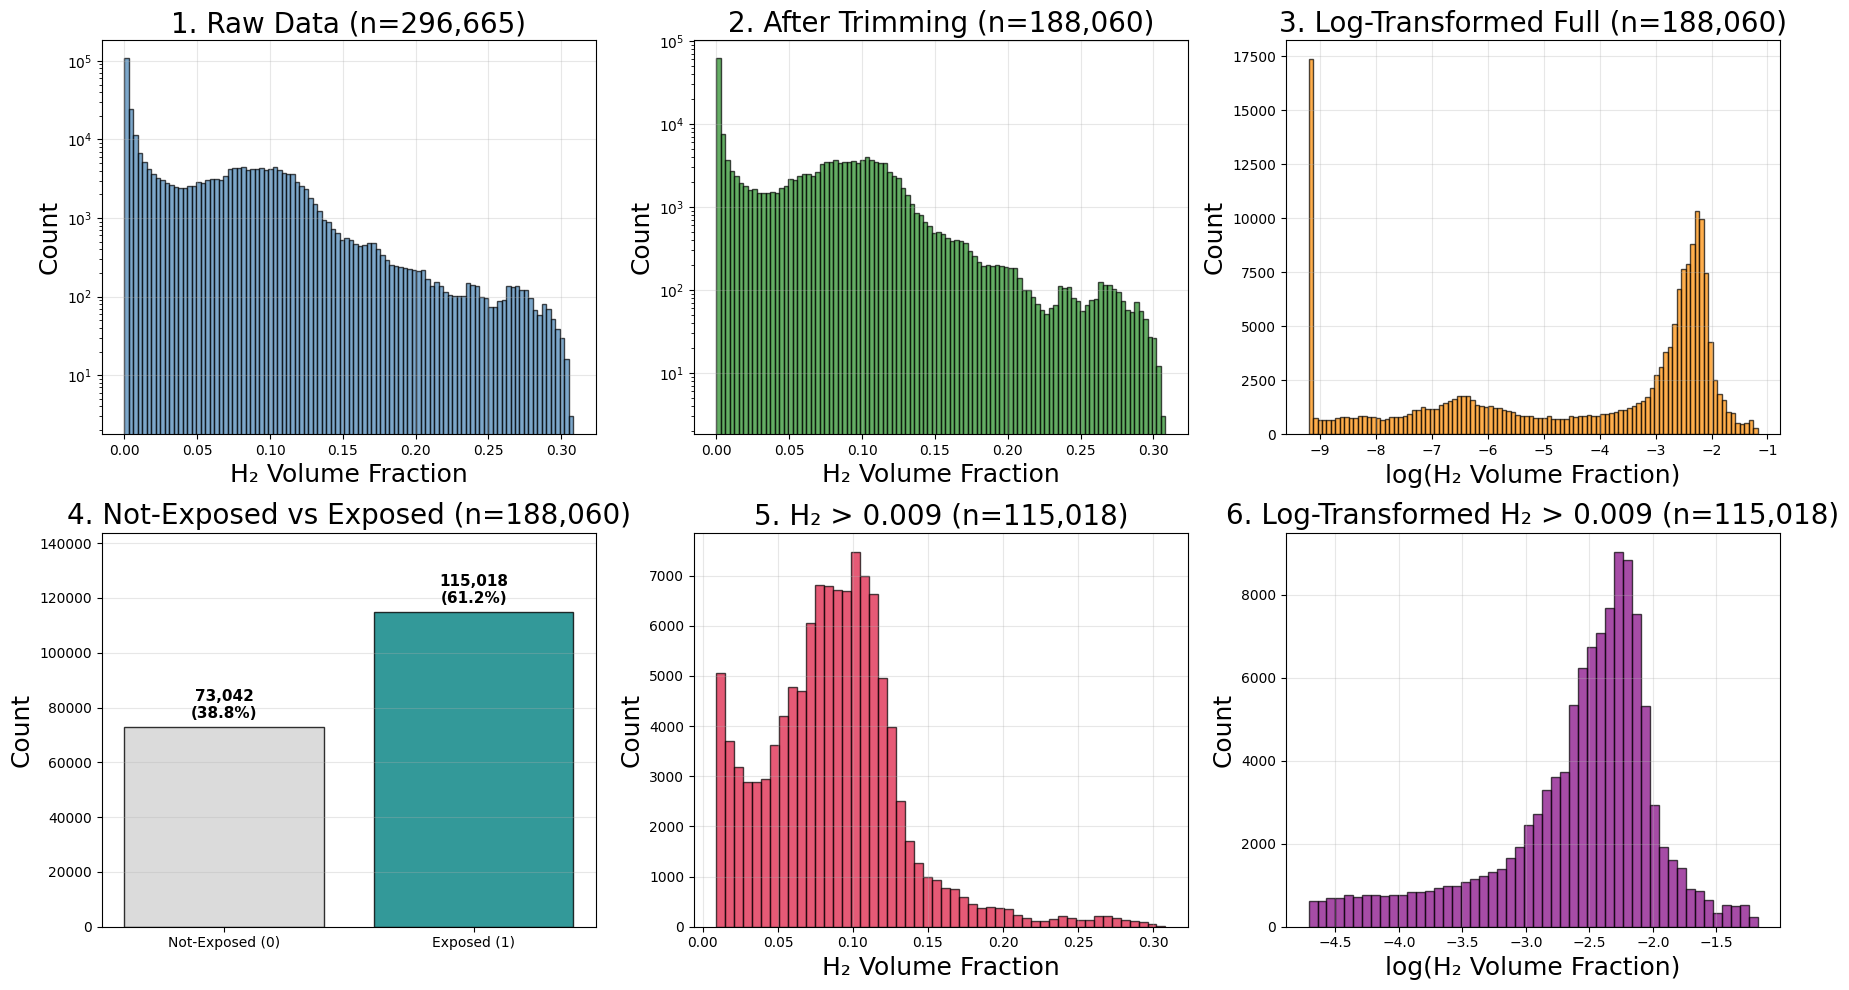

1. Raw data stats:
count    2.966650e+05
mean     4.215154e-02
std      5.203003e-02
min      1.211063e-13
25%      1.573871e-03
50%      1.129484e-02
75%      8.063445e-02
max      3.082763e-01
Name: h2_volume_fraction, dtype: float64

2. After 2D cut-off stats:
count    1.880600e+05
mean     5.390925e-02
std      5.524284e-02
min      1.211063e-13
25%      1.299774e-03
50%      4.544724e-02
75%      9.598873e-02
max      3.082763e-01
Name: h2_volume_fraction, dtype: float64

3. Log-transformed (full) stats:
count    188060.000000
mean         -4.460380
std           2.536918
min          -9.210340
25%          -6.571444
50%          -3.089005
75%          -2.342483
max          -1.176435
Name: h2_volume_fraction, dtype: float64

4. Active vs Inactive:
active
1    115018
0     73042
Name: count, dtype: int64

5. H₂ > 0.009 stats:
count    115018.000000
mean          0.087243
std           0.046115
min           0.009000
25%           0.057250
50%           0.086695
75%           0.111

In [13]:
# Filter for high-concentration samples
df_high = df[df['h2_volume_fraction'] > 0.009].copy()

# Create figure with 6 histograms (2 rows, 3 cols)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# 1. Raw uncut data
ax = axes[0]
ax.hist(df_uncut['h2_volume_fraction'], bins=100, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('H₂ Volume Fraction', fontsize=18)
ax.set_ylabel('Count', fontsize=18)
ax.set_title(f'1. Raw Data (n={len(df_uncut):,})', fontsize=20)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# 2. After trimming / 2D cut-off
ax = axes[1]
ax.hist(df['h2_volume_fraction'], bins=100, color='forestgreen', edgecolor='black', alpha=0.7)
ax.set_xlabel('H₂ Volume Fraction', fontsize=18)
ax.set_ylabel('Count', fontsize=18)
ax.set_title(f'2. After Trimming (n={len(df):,})', fontsize=20)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# 3. After log transform on full trimmed data
ax = axes[2]
h2_log = np.log(df['h2_volume_fraction'] + 1e-4)
ax.hist(h2_log, bins=100, color='darkorange', edgecolor='black', alpha=0.7)
ax.set_xlabel(f'log(H₂ Volume Fraction)', fontsize=18)
ax.set_ylabel('Count', fontsize=18)
ax.set_title(f'3. Log-Transformed Full (n={len(df):,})', fontsize=20)
ax.grid(True, alpha=0.3)

# 4. Active vs Inactive labels in cut-off data
ax = axes[3]
active_counts = df['active'].value_counts().sort_index()
colors = ['lightgray', 'teal']
bars = ax.bar(['Not-Exposed (0)', 'Exposed (1)'], active_counts.values, color=colors, edgecolor='black', alpha=0.8)
ax.set_ylabel('Count', fontsize=18)
ax.set_title(f'4. Not-Exposed vs Exposed (n={len(df):,})', fontsize=20)
for bar, count in zip(bars, active_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(df)*0.01,
            f'{count:,}\n({100*count/len(df):.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, max(active_counts.values) * 1.25)
ax.grid(True, alpha=0.3, axis='y')

# 5. High-concentration only (> 0.009)
ax = axes[4]
ax.hist(df_high['h2_volume_fraction'], bins=50, color='crimson', edgecolor='black', alpha=0.7)
ax.set_xlabel('H₂ Volume Fraction', fontsize=18)
ax.set_ylabel('Count', fontsize=18)
ax.set_title(f'5. H₂ > 0.009 (n={len(df_high):,})', fontsize=20)
ax.grid(True, alpha=0.3)

# 6. Log transform of high-concentration samples
ax = axes[5]
h2_high_log = np.log(df_high['h2_volume_fraction'])
ax.hist(h2_high_log, bins=50, color='purple', edgecolor='black', alpha=0.7)
ax.set_xlabel(f'log(H₂ Volume Fraction)', fontsize=18)
ax.set_ylabel('Count', fontsize=18)
ax.set_title(f'6. Log-Transformed H₂ > 0.009 (n={len(df_high):,})', fontsize=20)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('h2_histogram_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary stats
print("=" * 50)
print("1. Raw data stats:")
print(df_uncut['h2_volume_fraction'].describe())
print(f"\n2. After 2D cut-off stats:")
print(df['h2_volume_fraction'].describe())
print(f"\n3. Log-transformed (full) stats:")
print(h2_log.describe())
print(f"\n4. Active vs Inactive:")
print(df['active'].value_counts())
print(f"\n5. H₂ > 0.009 stats:")
print(df_high['h2_volume_fraction'].describe())
print(f"\n6. Log-transformed (H₂ > 0.009) stats:")
print(h2_high_log.describe())

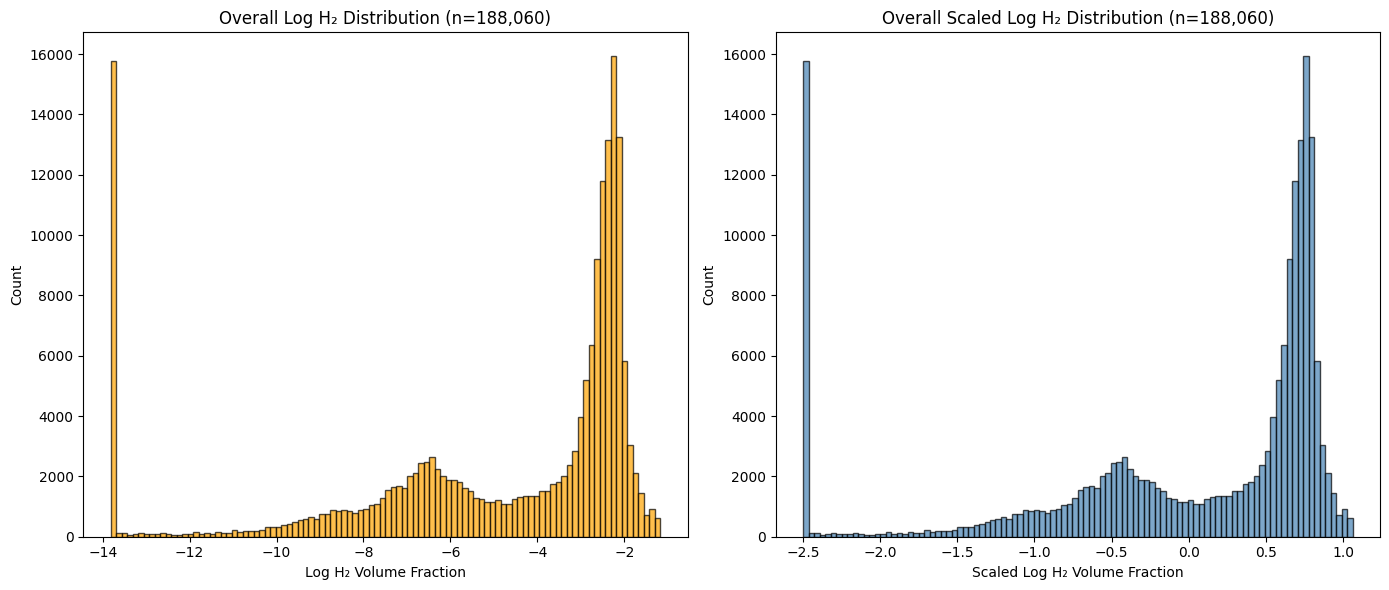

In [9]:
from sklearn.preprocessing import MaxAbsScaler, StandardScaler

h2_log = np.log((df['h2_volume_fraction'].values + 1e-6))
h2_scaler = StandardScaler()
h2_scaled = h2_scaler.fit_transform(h2_log.reshape(-1,1))
# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# 1. Overall distribution
ax = axes[1]
ax.hist(h2_scaled, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Scaled Log H₂ Volume Fraction')
ax.set_ylabel('Count')
ax.set_title(f'Overall Scaled Log H₂ Distribution (n={len(df):,})')

ax = axes[0]
ax.hist(h2_log, bins=100, color='orange', edgecolor='black', alpha=0.7)
ax.set_xlabel('Log H₂ Volume Fraction')
ax.set_ylabel('Count')
ax.set_title(f'Overall Log H₂ Distribution (n={len(df):,})')
plt.tight_layout()
plt.savefig('log_h2_histogram.png', dpi=150)
plt.show()

In [15]:
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv('data/unified_raw_two_modes.csv')

mass_scaler = StandardScaler()
time_scaler = StandardScaler()
X = df[['time', 'mass_flow', 'y', 'z']].values
time_scaled = time_scaler.fit_transform(X[:,0].reshape(-1,1))
mass_flow_scaled = mass_scaler.fit_transform(X[:,1].reshape(-1,1))
distance_scaler = StandardScaler()
distance_scaler.fit(X[:,2:])
yz_scaled = distance_scaler.transform(X[:,2:])

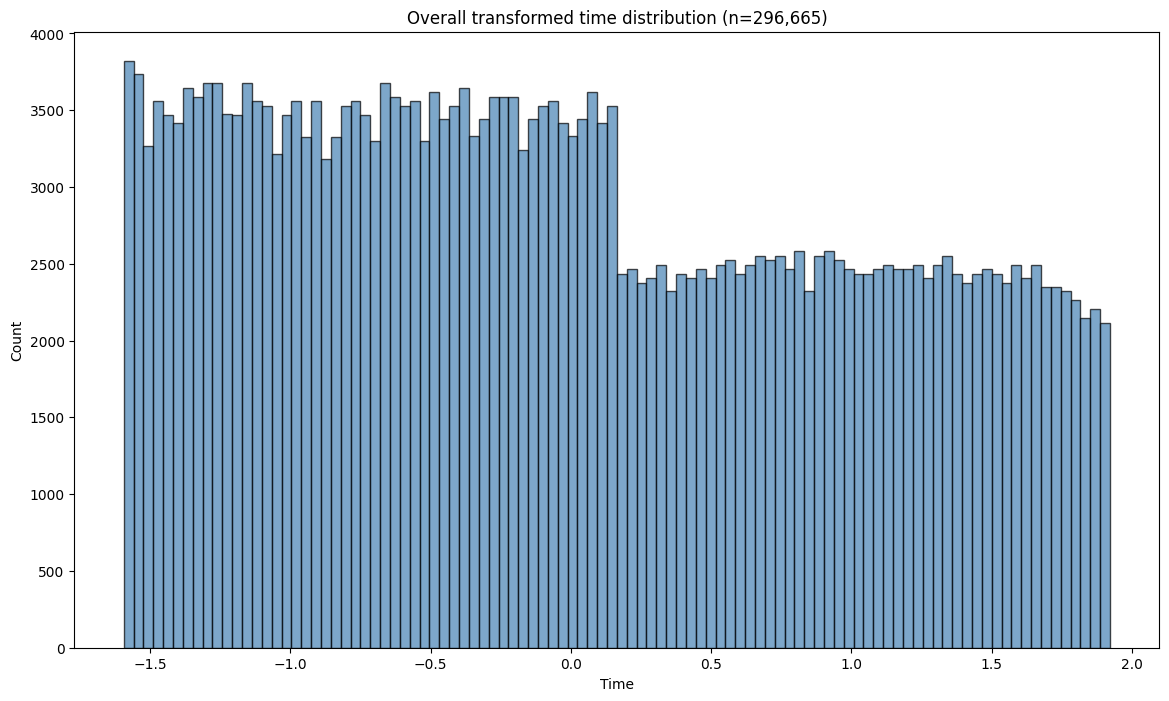

In [99]:
# Create figure
fig, ax = plt.subplots(figsize=(14, 8))


# 1. Overall distribution
ax.hist(time_scaled, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Time')
ax.set_ylabel('Count')
ax.set_title(f'Overall transformed time distribution (n={len(df):,})')

plt.show()

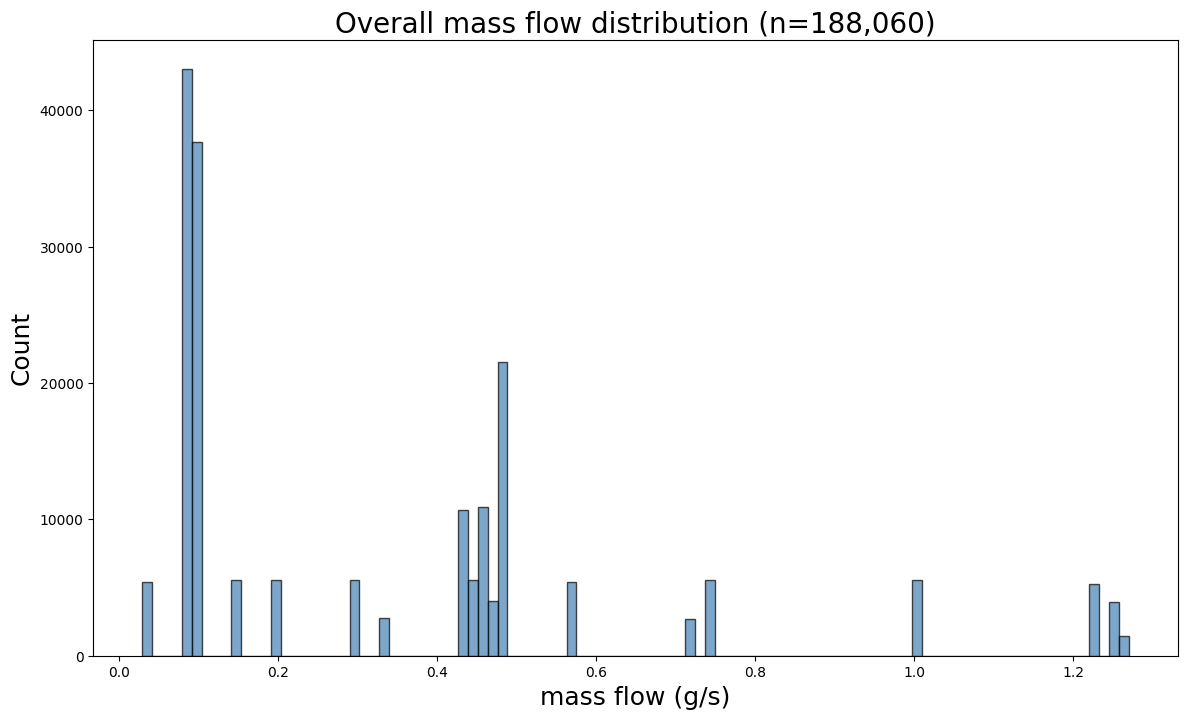

In [16]:
# Create figure
fig, ax = plt.subplots(figsize=(14, 8))


# 1. Overall distribution
ax.hist(X[:,1], bins=100, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('mass flow (g/s)', fontsize=18)
ax.set_ylabel('Count', fontsize=18)
ax.set_title(f'Overall mass flow distribution (n={len(df):,})', fontsize=20)

plt.show()

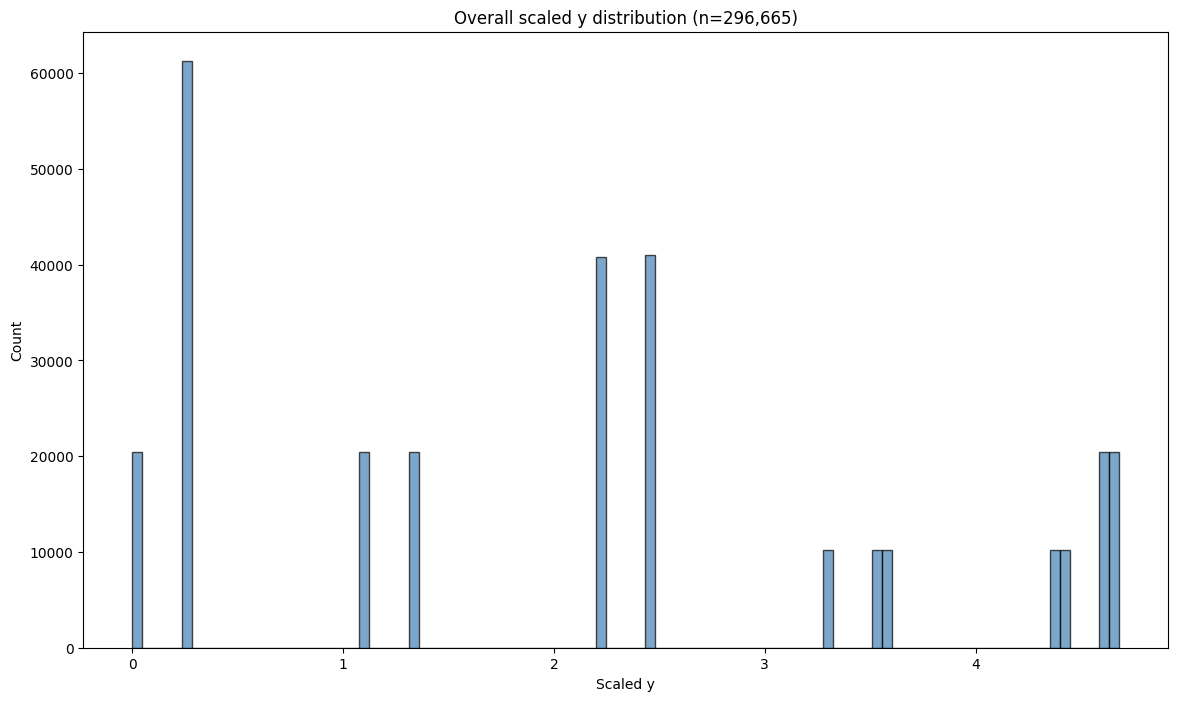

In [95]:
# Create figure
fig, ax = plt.subplots(figsize=(14, 8))


# 1. Overall distribution
ax.hist(X[:,2], bins=100, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Scaled y')
ax.set_ylabel('Count')
ax.set_title(f'Overall scaled y distribution (n={len(df):,})')

plt.show()

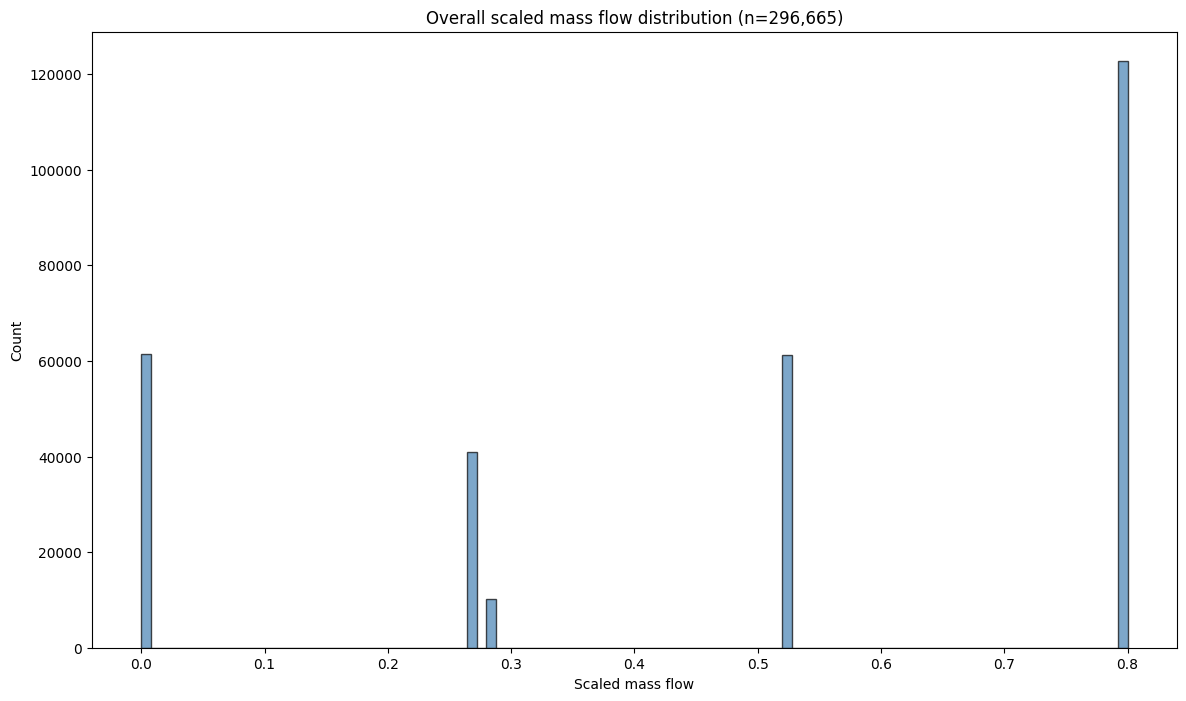

In [96]:
# Create figure
fig, ax = plt.subplots(figsize=(14, 8))


# 1. Overall distribution
ax.hist(X[:, 3], bins=100, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Scaled mass flow')
ax.set_ylabel('Count')
ax.set_title(f'Overall scaled mass flow distribution (n={len(df):,})')

plt.show()